<a href="https://colab.research.google.com/github/julianakbalestrin/Monitoramento_Ambiental_com_Sensores_e_Microcontroladores/blob/main/PLANT___Experimento_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PLANT — Experimento B: câmara estática com fitônia

Campanha de 14 a 18/09/2026 · sondas SCD40 nas placas **ESP-549C71** (azul) e **ESP-14FA61** (laranja).

| Parte | Origem | Conteúdo |
|---|---|---|
| 1 | Código 1 do professor — *CO2 — Fitônia — câmara estática* | leitura e limpeza, série completa, intercomparação, ciclo diário |
| 2 | Código 2 do professor — *Exemplo Regressão Linear 14FA61 × 549C71* | regressão com e sem intercepto, correção, diagrama de Taylor; validação fora da janela |
| 3 | Dica do final da aula + literatura | balanço de massa com $C_0$ = atmosfera, $Q_{10}$ / Arrhenius, fotossíntese; comparação com Machado et al. (2005) e Mundim et al. (2020) |
| 4 | — | figuras do relatório (PDF) e resumo dos resultados |

**Convenções gráficas:** noites sombreadas em azul-claro; intervalos excluídos do balanço hachurados; decimais com vírgula.

In [1]:
# ============ Configuração ============
import os, sys, subprocess, warnings
if not os.path.exists('dados.csv'):
    subprocess.run(['gdown', '1QDjHTB4MDQsFta_GvcbVZp94g9iWcJJd', '-O', 'dados.csv'], check=True)
try:
    import skill_metrics as skm
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'SkillMetrics'], check=True)
    import skill_metrics as skm
import numpy as np, pandas as pd, scipy, statsmodels
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.dates as mdates
import statsmodels.api as sm
from scipy import stats
from scipy.optimize import least_squares, curve_fit
from IPython.display import display
warnings.filterwarnings('ignore', category=FutureWarning)
print(f'pandas {pd.__version__} | numpy {np.__version__} | scipy {scipy.__version__} | '
      f'statsmodels {statsmodels.__version__} | matplotlib {mpl.__version__}')

pandas 2.2.3 | numpy 2.1.3 | scipy 1.16.3 | statsmodels 0.15.0 | matplotlib 3.10.0


In [2]:
# ============ Parâmetros (todas as escolhas da análise num só lugar) ============
MINHAS = ['ESP-549C71', 'ESP-14FA61']                      # A e B
FLUXO  = ['ESP-104F0B', 'ESP-B4988A', 'ESP-F1F050']        # sondas que registram o ar externo (atmosfera)
FAIXA_CO2 = (350, 5000)                                    # ppm válidos
INICIO_ESTAVEL = '2026-09-15 12:00'                        # período estável (código 1 do professor)
JANELA_EXEMPLO = ('2026-09-14 14:14', '2026-09-14 15:08:20')   # arquivo de calibração do código 2
INICIO_REGRESSAO = '2026-09-14 14:41:00'                   # início da regressão no código 2
ESPEC_SCD40 = (50, 0.05)                                   # ±(50 ppm + 5% da leitura)

P_ATM, V_AR, R_GAS = 90.6e3, 4.20e-3, 8.314                # Pa, m³, J/(mol·K)
A_SOLO = 0.0133                                             # m² (boca do vaso, Ø 13 cm)
TAU_H, TAU_FAIXA = 1.5, (1.1, 2.1)                          # h
Q10_ADOTADO = 2.0
LAT, LON, UTC = -25.43, -49.27, -3                          # Curitiba, horário local

EXCLUIR = [('2026-09-14 14:00', '2026-09-15 22:30', 'instalação, estabilização, 1ª noite em equilíbrio com o ar externo, vedação distinta em 15/09'),
           ('2026-09-16 07:30', '2026-09-16 10:45', 'chegada de pessoas e abertura para coleta'),
           ('2026-09-16 14:30', '2026-09-16 16:00', 'pico de CO2 na sala e abertura'),
           ('2026-09-16 18:00', '2026-09-16 18:30', 'queda abrupta sem causa identificada'),
           ('2026-09-17 09:30', '2026-09-17 10:45', 'abertura para coleta'),
           ('2026-09-18 07:15', '2026-09-18 10:00', 'chegada de pessoas, manuseio, fim da campanha')]
NOITES = {'15–16/09': ('2026-09-15 18:00', '2026-09-16 07:00'),
          '16–17/09': ('2026-09-16 18:00', '2026-09-17 07:00'),
          '17–18/09': ('2026-09-17 18:00', '2026-09-18 07:00')}
AR_EXTERNO = {'abertura de 16/09': ('2026-09-16 09:55', '2026-09-16 10:15'),
              'abertura de 17/09': ('2026-09-17 10:05', '2026-09-17 10:35'),
              '1ª noite (câmara em equilíbrio)': ('2026-09-14 20:00', '2026-09-15 06:00')}
# Literatura (comparações da seção 3.9)
Q10_LIT = (1.6, 2.6)          # respiração foliar, 15–40 °C: dados de Heskel et al. (2016) reanalisados por Mundim et al. (2020)
R_CITROS = (1.12, 1.17)       # respiração no escuro de citros, µmol m⁻² s⁻¹ de folha, a 28 °C (Machado et al., 2005)
T_CITROS = 28.0               # °C
PC_CITROS = (12.0, 17.5)      # ponto de compensação luminoso de folhas de citros, µmol m⁻² s⁻¹ (Machado et al., 2005)
EVENTOS = {'17/09, após abertura': ('2026-09-17 10:20', '2026-09-17 14:10'),
           '16/09, após pico na sala': ('2026-09-16 15:25', '2026-09-16 17:10'),
           '15–16/09, relaxação noturna': ('2026-09-15 22:00', '2026-09-16 06:00')}

In [3]:
# ============ Estilo gráfico ============
# ---------------- Estilo gráfico ----------------
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, MaxNLocator

COR = dict(A='#1B4F8A', B='#E8833A', atm='#4A4A4A', reg='#C0392B', sem='#2E8B57', com='#8E44AD', est='#1B4F8A',
           M0='#8C8C8C', M1='#1B4F8A', M2='#C0392B', M3='#2E8B57', noite='#EDF2F8', excl='#BDBDBD', texto='#333333')
N1, N2 = 'ESP-549C71', 'ESP-14FA61'

def estilo_params(escala='notebook'):
    b = 10.5 if escala == 'notebook' else 8.5
    return {
        'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'figure.facecolor': 'white',
        'font.family': 'DejaVu Sans', 'font.size': b,
        'axes.titlesize': b + 0.5, 'axes.titleweight': 'semibold', 'axes.titlelocation': 'left', 'axes.titlepad': 8,
        'axes.labelsize': b, 'axes.labelcolor': COR['texto'], 'axes.edgecolor': '#9A9A9A', 'axes.linewidth': 0.8,
        'axes.spines.top': False, 'axes.spines.right': False,
        'axes.grid': True, 'axes.grid.axis': 'y', 'grid.color': '#E9E9E9', 'grid.linewidth': 0.8,
        'xtick.color': '#555555', 'ytick.color': '#555555', 'xtick.labelsize': b - 1, 'ytick.labelsize': b - 1,
        'xtick.major.size': 3, 'ytick.major.size': 3, 'xtick.minor.size': 1.5,
        'legend.frameon': True, 'legend.framealpha': 0.9, 'legend.edgecolor': 'none', 'legend.facecolor': 'white',
        'legend.fontsize': b - 1.5, 'legend.handlelength': 1.6, 'legend.borderaxespad': 0.4,
        'lines.linewidth': 1.2, 'lines.markersize': 4,
        'hatch.color': COR['excl'], 'hatch.linewidth': 0.5}

def estilo(escala='notebook'):
    mpl.rcParams.update(estilo_params(escala))

virg = FuncFormatter(lambda v, p: f'{v:g}'.replace('.', ',').replace('-', '−'))
def br(v, d=2): return f'{v:.{d}f}'.replace('.', ',').replace('-', '−')
def num(v, d=1, sinal=False):
    '''Número com vírgula decimal, sinal de menos tipográfico e sem "−0,0".'''
    v = 0.0 if abs(v) < 0.5*10**(-d) else v
    s = f'{v:+.{d}f}' if (sinal and v != 0) else f'{v:.{d}f}'
    return s.replace('.', ',').replace('-', '−')
def eq_reta(inc, intercepto, d_inc=3, d_int=1, x='x'):
    return f"y = {num(inc, d_inc)}{x} {'+' if intercepto >= 0 else '−'} {num(abs(intercepto), d_int)}"
def sem_lacunas(serie, limite='2min'):
    '''Remove NaN e reinsere quebras apenas onde a lacuna excede o limite (linhas contínuas nos gráficos).'''
    s = serie.dropna()
    if len(s) < 2: return s
    gap = s.index.to_series().diff() > pd.Timedelta(limite)
    quebras = pd.Series(np.nan, index=s.index[gap] - pd.Timedelta('1s'))
    return pd.concat([s, quebras]).sort_index()
def virgula(ax, eixos='xy'):
    if 'x' in eixos: ax.xaxis.set_major_formatter(virg)
    if 'y' in eixos: ax.yaxis.set_major_formatter(virg)

def eixo_datas(ax, rotulo=True):
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    if rotulo: ax.set_xlabel('')

def painel(ax, letra, texto, pad=None):
    ax.set_title(f'{letra}   {texto}' if letra else texto, loc='left', pad=pad)

def sombrear_noites(ax, idx, elev):
    ax.fill_between(idx, 0, 1, where=np.asarray(elev) < 0, transform=ax.get_xaxis_transform(),
                    color=COR['noite'], lw=0, zorder=0, step='mid')

def hachurar(ax, intervalos):
    for t0, t1, *_ in intervalos:
        ax.axvspan(pd.Timestamp(t0), pd.Timestamp(t1), facecolor='none', hatch='////', edgecolor=COR['excl'], lw=0, zorder=0)

def caixa(ax, texto, x=0.03, y=0.95, ha='left', va='top', **kw):
    ax.text(x, y, texto, transform=ax.transAxes, ha=ha, va=va, fontsize=mpl.rcParams['font.size'] - 1,
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#D5D5D5', lw=0.6, alpha=0.95), **kw)

def taylor(ax, sd_ref, pontos, rmax=None, rticks=None, niveis=None, unidade='ppm', rotulo_ref='referência',
           correl=(0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99)):
    '''Diagrama de Taylor em coordenadas cartesianas. pontos: lista de dict(rotulo, dp, r, cor, marcador).'''
    rmax = rmax or 1.25*max([sd_ref] + [p['dp'] for p in pontos])
    rticks = rticks if rticks is not None else MaxNLocator(5).tick_values(0, rmax)[1:-1]
    th = np.linspace(0, np.pi/2, 300)
    ax.set_aspect('equal'); ax.set_xlim(0, rmax*1.02); ax.set_ylim(0, rmax*1.02); ax.grid(False)
    for r_ in rticks:
        ax.plot(r_*np.cos(th), r_*np.sin(th), color='#E6E6E6', lw=0.8, zorder=0)
    ax.plot(rmax*np.cos(th), rmax*np.sin(th), color='#9A9A9A', lw=0.9, zorder=1)
    for c in correl:
        a = np.arccos(c)
        ax.plot([0, rmax*np.cos(a)], [0, rmax*np.sin(a)], color='#E6E6E6', lw=0.8, zorder=0)
        ax.text(1.035*rmax*np.cos(a), 1.035*rmax*np.sin(a), f'{c:g}'.replace('.', ','), ha='left', va='center',
                fontsize=mpl.rcParams['font.size'] - 1.5, color='#555555', rotation=np.degrees(a), rotation_mode='anchor')
    ax.text(1.2*rmax*np.cos(np.radians(52)), 1.2*rmax*np.sin(np.radians(52)), 'correlação', rotation=-38,
            ha='center', va='center', fontsize=mpl.rcParams['font.size'] - 0.5, color='#555555')
    X, Y = np.meshgrid(np.linspace(0, rmax, 400), np.linspace(0, rmax, 400))
    Z = np.sqrt((X - sd_ref)**2 + Y**2); Z[np.hypot(X, Y) > rmax] = np.nan
    if niveis is None: niveis = MaxNLocator(4).tick_values(0, 0.9*np.nanmax(Z))[1:]
    cs = ax.contour(X, Y, Z, levels=niveis, colors='#A8A8A8', linestyles=':', linewidths=1.0, zorder=1)
    ax.clabel(cs, fmt=lambda v: f'{v:g}'.replace('.', ','), fontsize=mpl.rcParams['font.size'] - 2.5, inline_spacing=2)
    ax.plot(sd_ref*np.cos(th), sd_ref*np.sin(th), color='#6B6B6B', lw=0.9, ls='--', zorder=1)
    ax.plot(sd_ref, 0, marker='*', ms=14, color='black', clip_on=False, zorder=6, ls='none', label=rotulo_ref)
    for p in pontos:
        ax.plot(p['dp']*p['r'], p['dp']*np.sqrt(max(0, 1 - p['r']**2)), marker=p.get('marcador', 'o'), ms=9,
                color=p['cor'], mec='white', mew=0.9, ls='none', zorder=7, label=p['rotulo'], clip_on=False)
    ax.set_xticks(list(rticks)); ax.set_yticks(list(rticks)); virgula(ax)
    ax.set_xlabel(f'desvio-padrão ({unidade})' if unidade else 'desvio-padrão normalizado')
    ax.set_ylabel(f'desvio-padrão ({unidade})' if unidade else 'desvio-padrão normalizado')
    ax.spines['left'].set_bounds(0, rmax); ax.spines['bottom'].set_bounds(0, rmax)
    return ax

estilo('notebook')

In [4]:
# ============ Funções de análise ============
def elevacao_solar(idx, lat=LAT, lon=LON, utc=UTC):
    '''Elevação solar (graus) — algoritmo simplificado da NOAA; idx em horário local.'''
    t = idx - pd.Timedelta(hours=utc); doy = np.asarray(t.dayofyear); hr = np.asarray(t.hour + t.minute/60)
    g = 2*np.pi/365*(doy - 1 + (hr - 12)/24)
    dec = (0.006918 - 0.399912*np.cos(g) + 0.070257*np.sin(g) - 0.006758*np.cos(2*g)
           + 0.000907*np.sin(2*g) - 0.002697*np.cos(3*g) + 0.00148*np.sin(3*g))
    eqt = 229.18*(0.000075 + 0.001868*np.cos(g) - 0.032077*np.sin(g) - 0.014615*np.cos(2*g) - 0.040849*np.sin(2*g))
    ha = np.radians((hr*60 + eqt + 4*lon)/4 - 180); la = np.radians(lat)
    return np.degrees(np.arcsin(np.sin(la)*np.sin(dec) + np.cos(la)*np.cos(dec)*np.cos(ha)))

def regressao(x, y, hac=True, lags=3):
    '''MQO com intercepto; erros-padrão robustos à autocorrelação (Newey-West) quando hac=True.'''
    X = sm.add_constant(np.asarray(x, float))
    return sm.OLS(np.asarray(y, float), X).fit(**({'cov_type': 'HAC', 'cov_kwds': {'maxlags': lags}} if hac else {}))

def deming(x, y, lam=1.0):
    x, y = np.asarray(x, float), np.asarray(y, float)
    sxx, syy, sxy = ((x - x.mean())**2).sum(), ((y - y.mean())**2).sum(), ((x - x.mean())*(y - y.mean())).sum()
    b = (syy - lam*sxx + np.sqrt((syy - lam*sxx)**2 + 4*lam*sxy**2))/(2*sxy)
    return y.mean() - b*x.mean(), b

def allan(serie, janelas_min):
    '''Desvio de Allan (não sobreposto) de uma série regular de 1 min; blocos com lacunas são descartados.'''
    out = {}
    for m in janelas_min:
        blocos = serie.resample(f'{m}min').agg(['mean', 'count'])
        med = blocos['mean'].where(blocos['count'] >= 0.9*m)
        d = med.diff().dropna()
        if len(d) >= 2: out[m] = np.sqrt(0.5*np.mean(d**2))
    return out

def simula(seg, tau, r, q10=1.0, Tref=17.0, sem_vaz=False, dt=5/60):
    '''Integra n dC/dt = (n/τ)(C0 − C) + S com solução exata em cada passo (estável para qualquer τ).
    r: termo de reação em ppm/h a Tref; forçantes C0 e T mantidas constantes dentro do passo.'''
    C = np.empty(len(seg)); C[0] = seg.C.iloc[0]
    C0 = seg.C0.interpolate().bfill().ffill().values; T = seg['T'].interpolate().bfill().ffill().values
    a = 0.0 if sem_vaz else np.exp(-dt/tau)
    for i in range(1, len(seg)):
        ri = r*q10**((T[i-1] - Tref)/10)
        C[i] = C[i-1] + ri*dt if sem_vaz else (C0[i-1] + ri*tau) + (C[i-1] - C0[i-1] - ri*tau)*a
    return C

def ajusta_transiente(seg):
    '''Ajuste de τ e r (constante) a um transiente; erro-padrão aproximado (resíduos supostos independentes).'''
    obs = seg.C.interpolate().values
    res = least_squares(lambda p: simula(seg, p[0], p[1]) - obs, x0=[1.5, 60], bounds=([0.05, -500], [30, 800]))
    cov = np.linalg.inv(res.jac.T @ res.jac)*np.sum(res.fun**2)/(len(obs) - 2)
    return res.x, np.sqrt(np.diag(cov))

---
## Parte 1 — Código 1 do professor: *CO2 — Fitônia — câmara estática*
### 1.1 Leitura e limpeza

In [5]:
df = pd.read_csv('dados.csv', sep=';', decimal=',', parse_dates=['datetime']).set_index('datetime').sort_index()
n_bruto = len(df)
n_falha = int(((df.co2_ppm == 0) & (df.temperature_c == -45)).sum())
df = df[df.co2_ppm.between(*FAIXA_CO2)]                                   # descarta falhas do sensor
dur = (df.index.max() - df.index.min()).total_seconds()/3600
print(f'{len(df)} leituras | {df.board_id.nunique()} placas | {df.index.min():%d/%m %H:%M} a {df.index.max():%d/%m %H:%M} ({dur:.1f} h)')
print(f'removidas {n_bruto - len(df)} de {n_bruto} ({100*(n_bruto - len(df))/n_bruto:.3f}%), '
      f'das quais {n_falha} leituras não realizadas (CO2 = 0 ppm e T = −45 °C)')

# verificações adicionais nas sondas do grupo
g = df[df.board_id.isin(MINHAS)]
print(f'\nSondas do grupo — T: {g.temperature_c.min():.1f} a {g.temperature_c.max():.1f} °C | '
      f'UR: {g.humidity_rh.min():.0f} a {g.humidity_rh.max():.0f} %  (dentro dos limites do SCD40)')
for b_ in MINHAS:
    dt_ = g[g.board_id == b_].index.to_series().diff().dt.total_seconds()
    print(f'  {b_}: intervalo típico {dt_.median():.0f} s | lacunas > 1 min: {(dt_ > 60).sum()} | maior lacuna {dt_.max()/60:.0f} min')

215521 leituras | 9 placas | 14/09 14:14 a 18/09 09:57 (91.7 h)
removidas 53 de 215574 (0.025%), das quais 38 leituras não realizadas (CO2 = 0 ppm e T = −45 °C)

Sondas do grupo — T: 13.9 a 24.7 °C | UR: 56 a 90 %  (dentro dos limites do SCD40)
  ESP-549C71: intervalo típico 9 s | lacunas > 1 min: 4 | maior lacuna 33 min
  ESP-14FA61: intervalo típico 10 s | lacunas > 1 min: 9 | maior lacuna 60 min


### 1.2 Série temporal completa

Pontos pareados (1 min): 5423


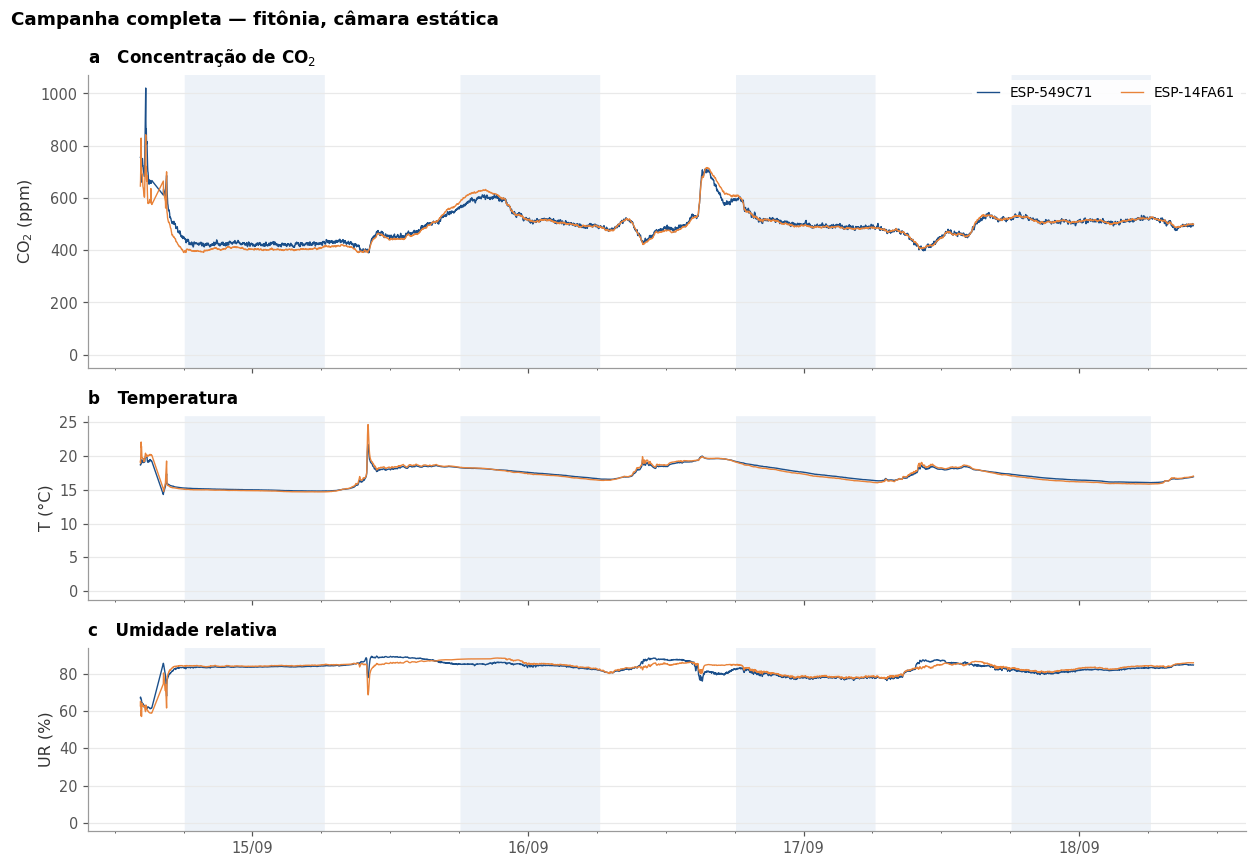

In [6]:
A = df[df.board_id == MINHAS[0]][['co2_ppm', 'temperature_c', 'humidity_rh']].resample('1min').mean()
B = df[df.board_id == MINHAS[1]][['co2_ppm', 'temperature_c', 'humidity_rh']].resample('1min').mean()
par = A.join(B, lsuffix='_A', rsuffix='_B').dropna()
elev_par = elevacao_solar(par.index)
print(f'Pontos pareados (1 min): {len(par)}')

fig, ax = plt.subplots(3, 1, figsize=(11.5, 8), sharex=True, gridspec_kw={'height_ratios': [1.6, 1, 1]})
for a_, (var, rot) in zip(ax, [('co2_ppm', 'CO$_2$ (ppm)'), ('temperature_c', 'T (°C)'), ('humidity_rh', 'UR (%)')]):
    sombrear_noites(a_, par.index, elev_par)
    a_.plot(par.index, par[f'{var}_A'], color=COR['A'], lw=0.9, label=MINHAS[0])
    a_.plot(par.index, par[f'{var}_B'], color=COR['B'], lw=0.9, label=MINHAS[1])
    a_.set_ylabel(rot); virgula(a_, 'y')
painel(ax[0], 'a', 'Concentração de CO$_2$'); painel(ax[1], 'b', 'Temperatura'); painel(ax[2], 'c', 'Umidade relativa')
ax[0].legend(loc='upper right', ncol=2); eixo_datas(ax[2])
fig.suptitle('Campanha completa — fitônia, câmara estática', x=0.01, ha='left', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

### 1.3 Período estável: intercomparação das sondas

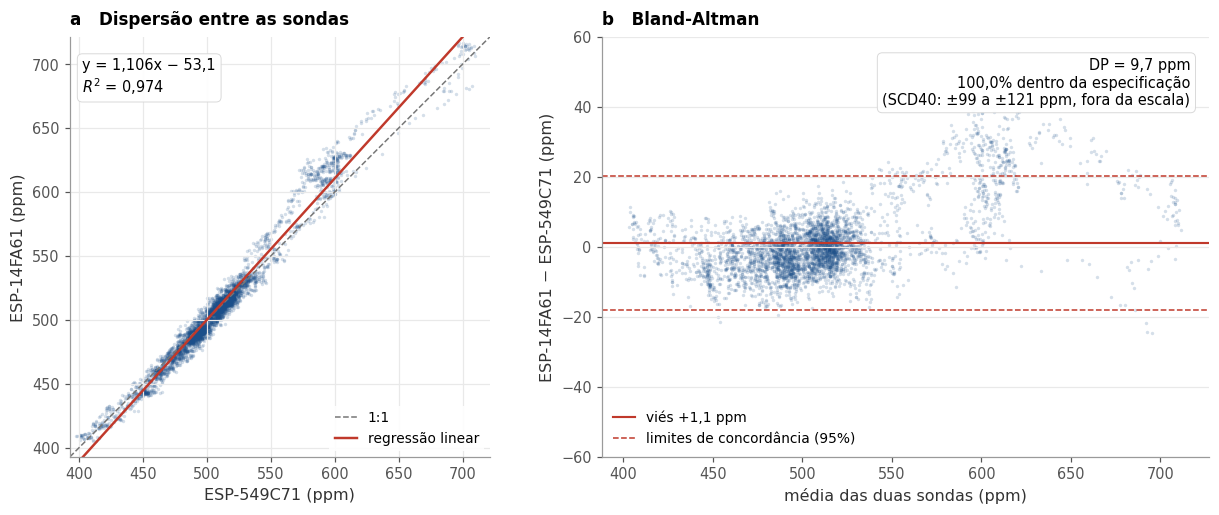

Viés: +1.11 ppm | DP: 9.71 ppm | dentro da especificação: 100.0%


In [7]:
est = par.loc[INICIO_ESTAVEL:]
a, b = est.co2_ppm_A.values, est.co2_ppm_B.values
dif, med = b - a, (a + b)/2
vies, dp = dif.mean(), dif.std(ddof=1)
spec = (ESPEC_SCD40[0] + ESPEC_SCD40[1]*med)*np.sqrt(2)   # SCD40 (o código original usava ±(30 + 3%), do SCD30)
m = stats.linregress(a, b)
dentro = 100*(np.abs(dif) <= spec).mean()

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.8), gridspec_kw={'width_ratios': [1, 1.25]})
lim = [min(a.min(), b.min()) - 5, max(a.max(), b.max()) + 5]
ax[0].scatter(a, b, s=5, color=COR['A'], alpha=0.18, lw=0)
ax[0].plot(lim, lim, color='#777777', ls='--', lw=1, label='1:1')
ax[0].plot(lim, m.intercept + m.slope*np.array(lim), color=COR['reg'], lw=1.6, label='regressão linear')
ax[0].set(xlim=lim, ylim=lim, xlabel=f'{MINHAS[0]} (ppm)', ylabel=f'{MINHAS[1]} (ppm)'); ax[0].set_aspect('equal')
ax[0].grid(True, axis='both'); ax[0].legend(loc='lower right')
caixa(ax[0], f'{eq_reta(m.slope, m.intercept)}\n$R^2$ = {br(m.rvalue**2, 3)}')
painel(ax[0], 'a', 'Dispersão entre as sondas')

ax[1].scatter(med, dif, s=5, color=COR['A'], alpha=0.18, lw=0)
ax[1].axhline(vies, color=COR['reg'], lw=1.4, label=f'viés {num(vies, 1, True)} ppm')
for s_ in (1, -1):
    ax[1].axhline(vies + s_*1.96*dp, color=COR['reg'], ls='--', lw=1, label='limites de concordância (95%)' if s_ == 1 else None)
ax[1].set(xlabel='média das duas sondas (ppm)', ylabel=f'{MINHAS[1]} − {MINHAS[0]} (ppm)', ylim=(-60, 60))
ax[1].legend(loc='lower left'); virgula(ax[1], 'y')
caixa(ax[1], f'DP = {br(dp, 1)} ppm\n{br(dentro, 1)}% dentro da especificação\n'
      f'(SCD40: ±{spec.min():.0f} a ±{spec.max():.0f} ppm, fora da escala)', x=0.97, ha='right')
painel(ax[1], 'b', 'Bland-Altman')
plt.tight_layout(); plt.show()
print(f'Viés: {vies:+.2f} ppm | DP: {dp:.2f} ppm | dentro da especificação: {dentro:.1f}%')

### 1.4 Ciclo diário: há sinal de planta?

O critério do código original compara a média horária de dia e de noite. Como a média horária é sensível a episódios isolados (aberturas, pessoas na sala), o gráfico mostra também a **mediana** sem os intervalos perturbados.

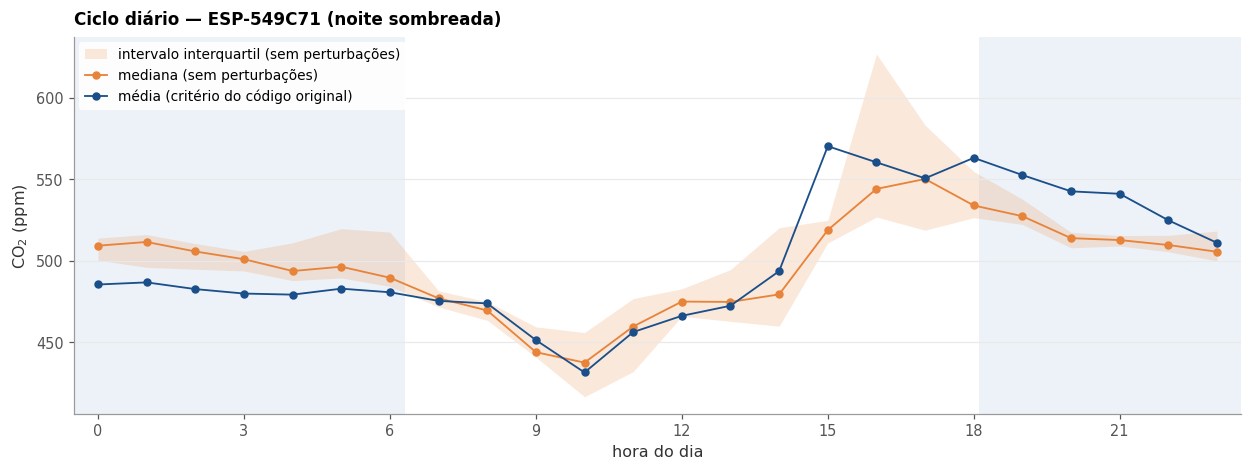

Média (critério original): dia 513 ppm | noite 483 ppm | diferença +30 ppm
Mediana sem perturbações:  dia 498 ppm | noite 503 ppm | diferença -5 ppm
-> o pico diurno da média vem de episódios de ocupação; nos dois casos, não há o acúmulo noturno esperado de uma câmara vedada


In [8]:
s = par.co2_ppm_A.loc['2026-09-15':]
ciclo = s.groupby(s.index.hour).mean()                               # critério do professor
ok = pd.Series(True, index=s.index)
for t0, t1, _ in EXCLUIR: ok.loc[t0:t1] = False
sr = s[ok]; q = sr.groupby(sr.index.hour).quantile([0.25, 0.5, 0.75]).unstack()

fig, ax = plt.subplots(figsize=(11.5, 4.4))
ax.axvspan(-0.5, 6.3, color=COR['noite'], lw=0, zorder=0); ax.axvspan(18.1, 23.5, color=COR['noite'], lw=0, zorder=0)
ax.fill_between(q.index, q[0.25], q[0.75], color=COR['B'], alpha=0.18, lw=0, label='intervalo interquartil (sem perturbações)')
ax.plot(q.index, q[0.5], 'o-', color=COR['B'], ms=4.5, label='mediana (sem perturbações)')
ax.plot(ciclo.index, ciclo.values, 'o-', color=COR['A'], ms=4.5, label='média (critério do código original)')
ax.set(xlim=(-0.5, 23.5), xticks=range(0, 24, 3), xlabel='hora do dia', ylabel='CO$_2$ (ppm)')
ax.legend(loc='upper left'); painel(ax, '', f'Ciclo diário — {MINHAS[0]} (noite sombreada)')
plt.tight_layout(); plt.show()

dia, noite = ciclo.loc[12:16].mean(), ciclo.loc[0:5].mean()
dia_r, noite_r = q[0.5].loc[12:16].mean(), q[0.5].loc[0:5].mean()
print(f'Média (critério original): dia {dia:.0f} ppm | noite {noite:.0f} ppm | diferença {dia - noite:+.0f} ppm')
print(f'Mediana sem perturbações:  dia {dia_r:.0f} ppm | noite {noite_r:.0f} ppm | diferença {dia_r - noite_r:+.0f} ppm')
print('-> o pico diurno da média vem de episódios de ocupação; nos dois casos, não há o acúmulo noturno'
      ' esperado de uma câmara vedada')

---
## Parte 2 — Código 2 do professor: *Exemplo Regressão Linear 14FA61 × 549C71*

O exemplo baixava `sensor_data_calibracao.json`. Aqui são usadas as mesmas leituras, já limpas, retiradas do CSV na mesma janela de 14/09 — os coeficientes são idênticos aos do exemplo.

1937 leituras de 8 placas na janela | tabela consolidada (10 s): (322, 24)


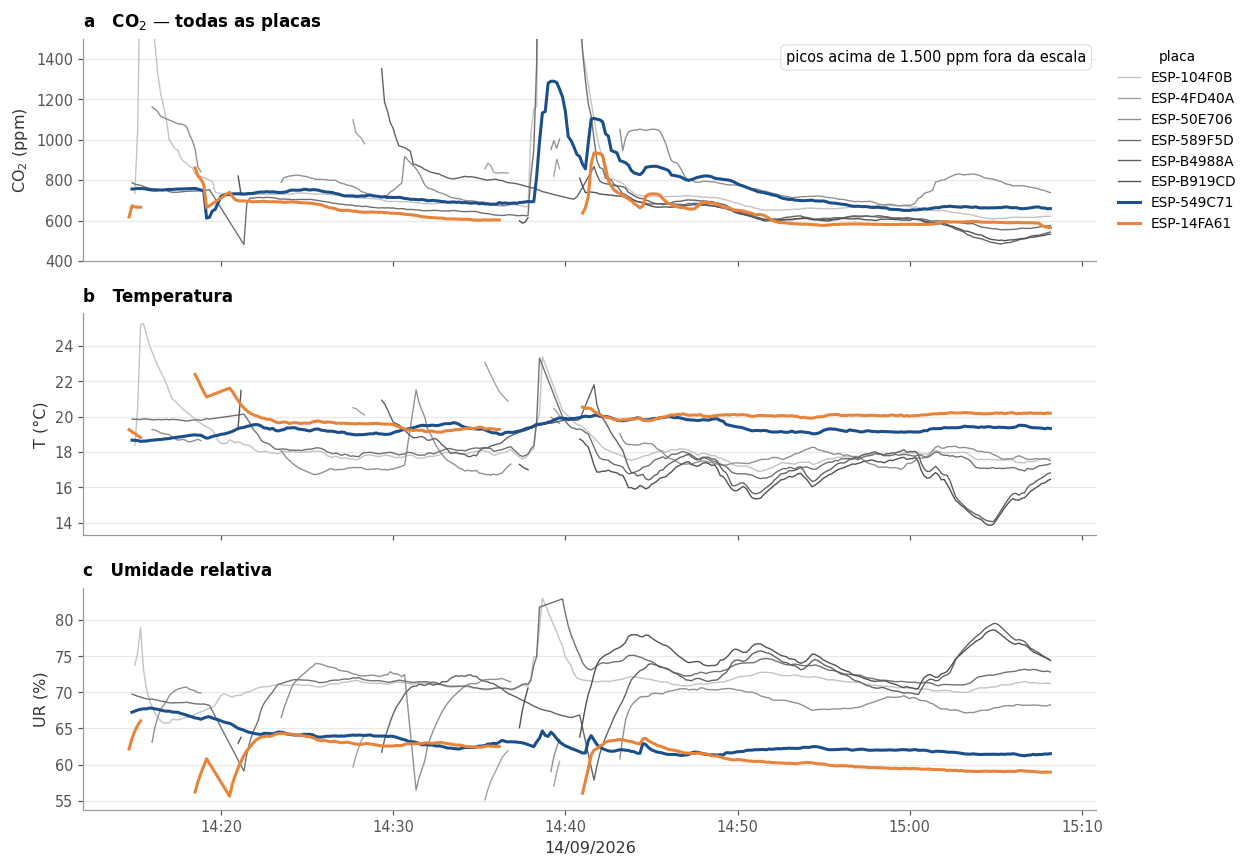

In [9]:
janela = df.loc[JANELA_EXEMPLO[0]:JANELA_EXEMPLO[1]]
df_consolidated_sensors = pd.concat(
    [janela[janela.board_id == b_][['co2_ppm', 'temperature_c', 'humidity_rh']].resample('10s').mean().add_prefix(f'{b_}_')
     for b_ in sorted(janela.board_id.unique())], axis=1, sort=True)
placas = sorted(janela.board_id.unique())
print(f'{len(janela)} leituras de {len(placas)} placas na janela | tabela consolidada (10 s): {df_consolidated_sensors.shape}')

cinzas = plt.cm.Greys(np.linspace(0.35, 0.75, len(placas)))
fig, ax = plt.subplots(3, 1, figsize=(11.5, 8), sharex=True)
for a_, (var, rot) in zip(ax, [('co2_ppm', 'CO$_2$ (ppm)'), ('temperature_c', 'T (°C)'), ('humidity_rh', 'UR (%)')]):
    for c_, b_ in zip(cinzas, placas):
        if b_ in MINHAS: continue
        s_ = sem_lacunas(df_consolidated_sensors[f'{b_}_{var}']); a_.plot(s_.index, s_.values, color=c_, lw=0.9, label=b_)
    for b_, cor in zip(MINHAS, (COR['A'], COR['B'])):
        s_ = sem_lacunas(df_consolidated_sensors[f'{b_}_{var}']); a_.plot(s_.index, s_.values, color=cor, lw=2, label=b_)
    a_.set_ylabel(rot); virgula(a_, 'y')
ax[0].set_ylim(400, 1500); caixa(ax[0], 'picos acima de 1.500 ppm fora da escala', x=0.99, ha='right')
painel(ax[0], 'a', 'CO$_2$ — todas as placas'); painel(ax[1], 'b', 'Temperatura'); painel(ax[2], 'c', 'Umidade relativa')
ax[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), title='placa', title_fontsize=9)
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')); ax[2].set_xlabel('14/09/2026')
plt.tight_layout(); plt.show()

156 pares de 10 s | correlação entre as sondas: 0.97


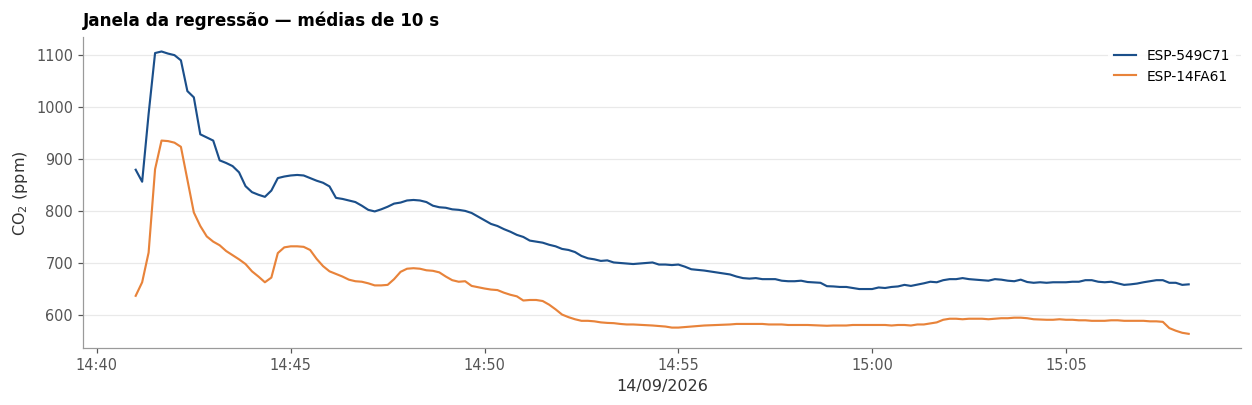

In [10]:
d2 = janela[janela.index >= INICIO_REGRESSAO]
df_549C71_sel_10s = d2[d2.board_id == 'ESP-549C71'][['co2_ppm']].resample('10s').mean()
df_14FA61_sel_10s = d2[d2.board_id == 'ESP-14FA61'][['co2_ppm']].resample('10s').mean()
data = pd.concat([df_549C71_sel_10s.co2_ppm.rename('co2_ppm_549C71'),
                  df_14FA61_sel_10s.co2_ppm.rename('co2_ppm_14FA61')], axis=1).dropna()
correlation = data.co2_ppm_549C71.corr(data.co2_ppm_14FA61)
print(f'{len(data)} pares de 10 s | correlação entre as sondas: {correlation:.2f}')

fig, ax = plt.subplots(figsize=(11.5, 3.8))
ax.plot(data.index, data.co2_ppm_549C71, color=COR['A'], lw=1.4, label=MINHAS[0])
ax.plot(data.index, data.co2_ppm_14FA61, color=COR['B'], lw=1.4, label=MINHAS[1])
ax.set_ylabel('CO$_2$ (ppm)'); ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')); ax.set_xlabel('14/09/2026')
painel(ax, '', 'Janela da regressão — médias de 10 s')
plt.tight_layout(); plt.show()

### 2.1 Correção por regressão linear — sem e com coeficiente linear

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
co2_ppm_549C71     0.8448      0.003    304.198      0.000       0.839       0.850
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            127.6621     10.337     12.350      0.000     107.242     148.082
co2_ppm_549C71     0.6776      0.014     49.509      0.000       0.651       0.705

sem intercepto:  549C71 corrigido  = 0.8448 × 549C71      (R² não centrado = 0.998)
com intercepto:  549C71 corrigido2 = +127.66 + 0.6776 × 549C71   (R² = 0.941)
O R² sem intercepto é calculado em torno de zero, não da média: não é comparável ao do modelo com intercepto.


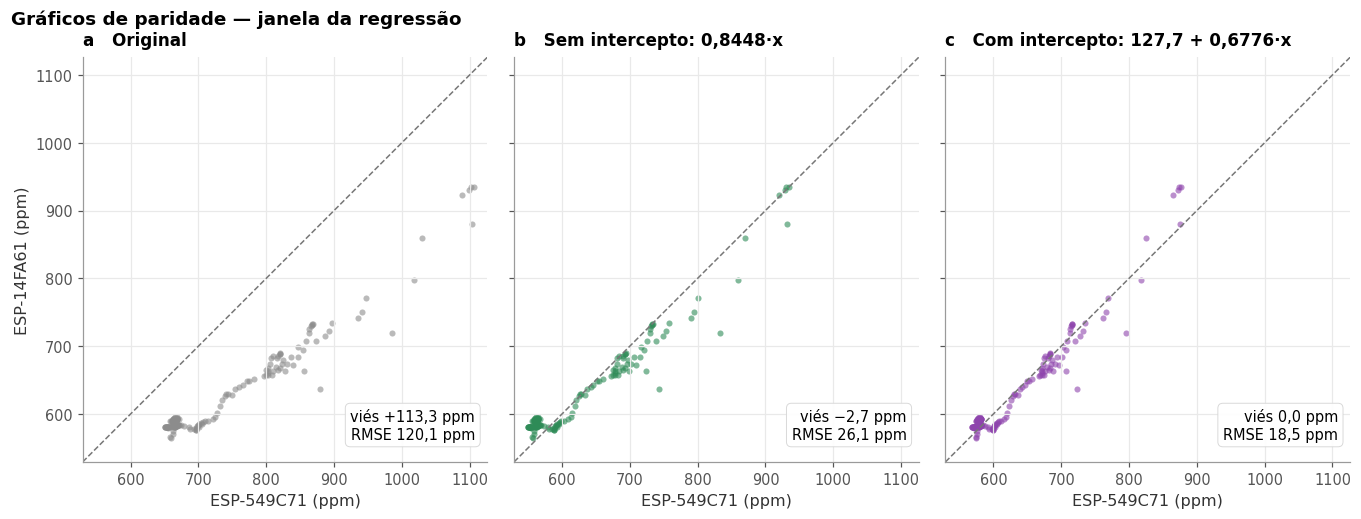

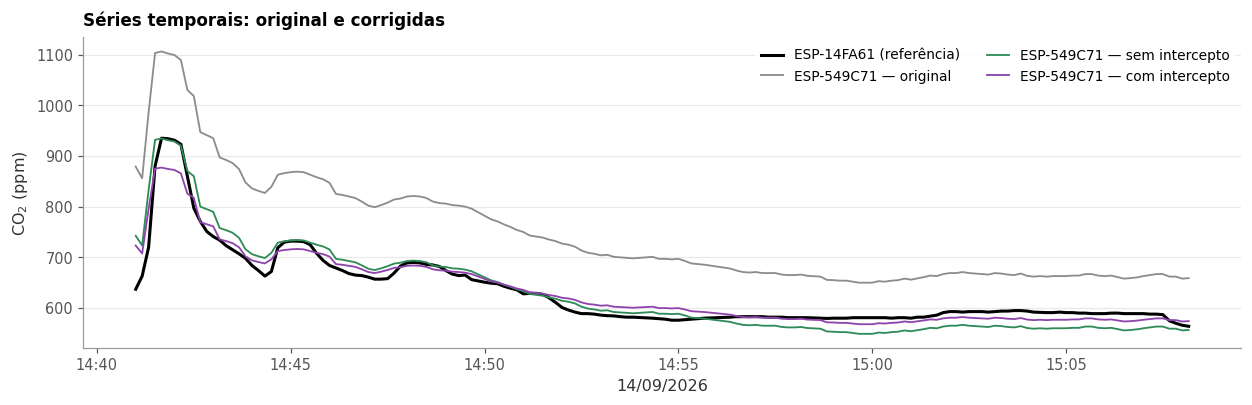

In [11]:
X = data['co2_ppm_549C71']; y = data['co2_ppm_14FA61']
model = sm.OLS(y, X).fit()                                   # 1) sem intercepto
model2 = sm.OLS(y, sm.add_constant(X)).fit()                 # 2) com intercepto
data['co2_ppm_549C71_corrected'] = model.predict(X)
data['co2_ppm_549C71_corrected2'] = model2.predict(sm.add_constant(X))
a1 = model.params.iloc[0]; b0, b1 = model2.params.iloc[0], model2.params.iloc[1]

print(model.summary().tables[1]); print(model2.summary().tables[1])
print(f'\nsem intercepto:  549C71 corrigido  = {a1:.4f} × 549C71      (R² não centrado = {model.rsquared:.3f})')
print(f'com intercepto:  549C71 corrigido2 = {b0:+.2f} + {b1:.4f} × 549C71   (R² = {model2.rsquared:.3f})')
print('O R² sem intercepto é calculado em torno de zero, não da média: não é comparável ao do modelo com intercepto.')

versoes = [('co2_ppm_549C71', 'Original', '#8C8C8C'),
           ('co2_ppm_549C71_corrected', f'Sem intercepto: {br(a1, 4)}·x', COR['sem']),
           ('co2_ppm_549C71_corrected2', f'Com intercepto: {br(b0, 1)} + {br(b1, 4)}·x', COR['com'])]
lim = [data.values.min() - 20, data.values.max() + 20]
fig, ax = plt.subplots(1, 3, figsize=(12.5, 4.5), sharey=True)
for a_, (col, rot, cor), letra in zip(ax, versoes, 'abc'):
    e = data[col] - data.co2_ppm_14FA61
    a_.plot(lim, lim, color='#777777', ls='--', lw=1)
    a_.scatter(data[col], data.co2_ppm_14FA61, s=16, color=cor, alpha=0.6, lw=0)
    a_.set(xlim=lim, ylim=lim, xlabel=f'{MINHAS[0]} (ppm)'); a_.set_aspect('equal'); a_.grid(True, axis='both')
    caixa(a_, f'viés {num(e.mean(), 1, True)} ppm\nRMSE {num(np.sqrt((e**2).mean()), 1)} ppm', x=0.97, y=0.05, ha='right', va='bottom')
    painel(a_, letra, rot)
ax[0].set_ylabel(f'{MINHAS[1]} (ppm)')
fig.suptitle('Gráficos de paridade — janela da regressão', x=0.01, ha='left', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11.5, 3.8))
ax.plot(data.index, data.co2_ppm_14FA61, color='black', lw=2, label=f'{MINHAS[1]} (referência)')
for col, rot, cor in versoes:
    ax.plot(data.index, data[col], color=cor, lw=1.2, label=f'{MINHAS[0]} — {rot.split(":")[0].lower()}')
ax.set_ylabel('CO$_2$ (ppm)'); ax.legend(loc='upper right', ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')); ax.set_xlabel('14/09/2026')
painel(ax, '', 'Séries temporais: original e corrigidas')
plt.tight_layout(); plt.show()

### 2.2 Diagrama de Taylor

Estatísticas calculadas com a SkillMetrics, como no exemplo. O **CRMSD** (*centered root mean square difference*) é o erro depois de remover a média de cada série: mede a reprodução das variações, independentemente do viés — por isso o viés e o RMSE são mostrados ao lado.

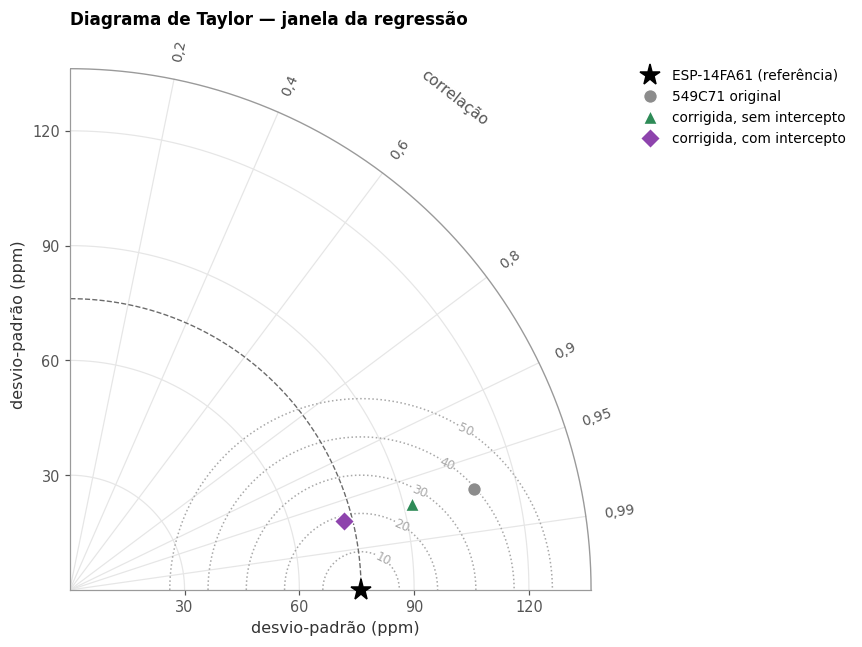

,desvio-padrão,CRMSD,correlação,viés,RMSE
série,,,,,
549C71 original,108.99,39.72,0.9700,+113.34,120.10
"corrigida, sem intercepto",92.08,25.98,0.9700,-2.66,26.12
"corrigida, com intercepto",73.85,18.51,0.9700,-0.00,18.51


Referência ESP-14FA61: desvio-padrão = 76.13 ppm


In [12]:
def metricas(tab, ref_col, series):
    ref = tab[ref_col].to_numpy(); linhas = []
    for rot, col in series.items():
        obs = tab[col].to_numpy(); st = skm.taylor_statistics(obs, ref)
        linhas.append({'série': rot, 'desvio-padrão': st['sdev'][1], 'CRMSD': st['crmsd'][1], 'correlação': st['ccoef'][1],
                       'viés': (obs - ref).mean(), 'RMSE': np.sqrt(((obs - ref)**2).mean())})
    return pd.DataFrame(linhas).set_index('série'), np.std(ref)
def mostra(t):
    display(t.style.format({'desvio-padrão': '{:.2f}', 'CRMSD': '{:.2f}', 'correlação': '{:.4f}', 'viés': '{:+.2f}', 'RMSE': '{:.2f}'}))

met_janela, sd_ref_janela = metricas(data, 'co2_ppm_14FA61', {'549C71 original': 'co2_ppm_549C71',
                                                              'corrigida, sem intercepto': 'co2_ppm_549C71_corrected',
                                                              'corrigida, com intercepto': 'co2_ppm_549C71_corrected2'})
fig, ax = plt.subplots(figsize=(8.5, 6))
taylor(ax, sd_ref_janela, [dict(rotulo=k_, dp=v['desvio-padrão'], r=v['correlação'], cor=c_, marcador=m_)
                           for (k_, v), c_, m_ in zip(met_janela.iterrows(), ['#8C8C8C', COR['sem'], COR['com']], 'o^D')],
       rotulo_ref=f'{MINHAS[1]} (referência)', niveis=[10, 20, 30, 40, 50])
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1)); painel(ax, '', 'Diagrama de Taylor — janela da regressão', pad=22)
plt.tight_layout(); plt.show()
mostra(met_janela); print(f'Referência {MINHAS[1]}: desvio-padrão = {sd_ref_janela:.2f} ppm')

### 2.3 A correção vale fora da janela em que foi ajustada?

A janela do exemplo coincide com a instalação (sondas ligadas havia menos de uma hora; CO₂ caindo de ~1.100 para ~650 ppm). As correções são aplicadas ao período estável da Parte 1 e comparadas com a regressão refeita nesse período.

Período estável (4198 médias de 1 min): 549C71 − 14FA61 = -1.11 ppm | r = 0.987
  sem intercepto: 14FA61 = 1.0030 × 549C71
  com intercepto: 14FA61 = -53.07 + 1.1062 × 549C71 (R² = 0.974)


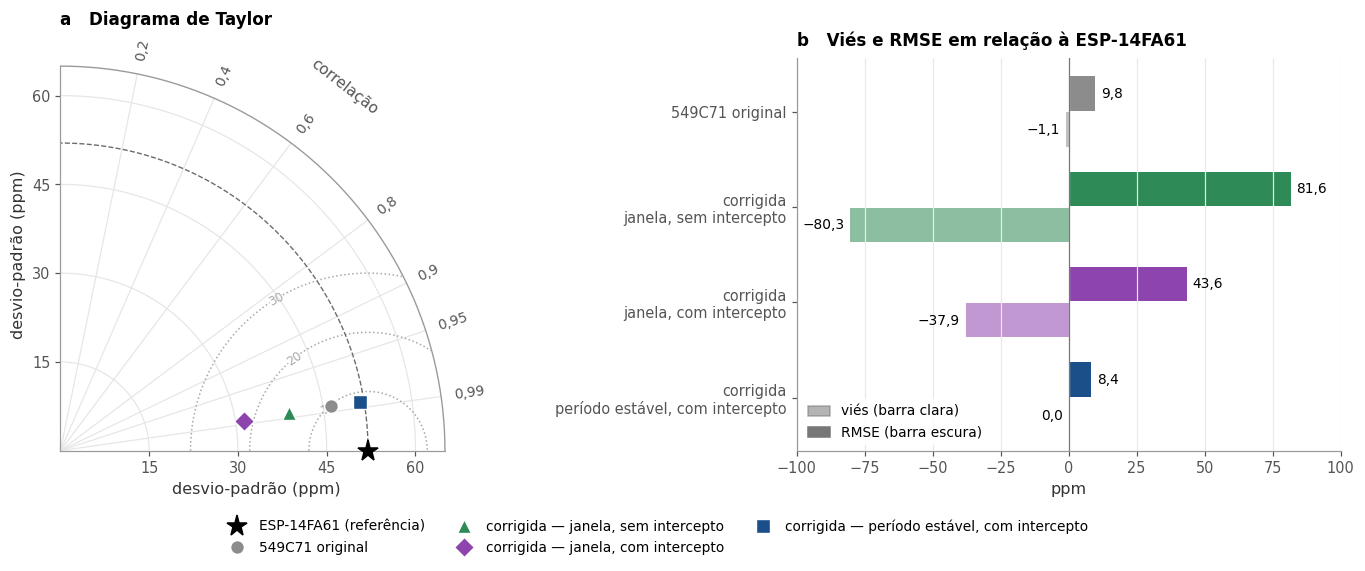

,desvio-padrão,CRMSD,correlação,viés,RMSE
série,,,,,
549C71 original,46.38,9.71,0.9869,-1.11,9.78
"corrigida — janela, sem intercepto",39.18,14.73,0.9869,-80.26,81.60
"corrigida — janela, com intercepto",31.42,21.57,0.9869,-37.89,43.60
"corrigida — período estável, com intercepto",51.31,8.37,0.9869,-0.00,8.37


In [13]:
val = est[['co2_ppm_A', 'co2_ppm_B']].rename(columns={'co2_ppm_A': 'co2_ppm_549C71', 'co2_ppm_B': 'co2_ppm_14FA61'})
m_est1 = sm.OLS(val.co2_ppm_14FA61, val.co2_ppm_549C71).fit()
m_est2 = sm.OLS(val.co2_ppm_14FA61, sm.add_constant(val.co2_ppm_549C71)).fit()
c0_est, c1_est = m_est2.params.iloc[0], m_est2.params.iloc[1]
val['janela_sem'] = a1*val.co2_ppm_549C71
val['janela_com'] = b0 + b1*val.co2_ppm_549C71
val['estavel_com'] = c0_est + c1_est*val.co2_ppm_549C71
print(f'Período estável ({len(val)} médias de 1 min): 549C71 − 14FA61 = {(val.co2_ppm_549C71 - val.co2_ppm_14FA61).mean():+.2f} ppm | '
      f'r = {val.co2_ppm_549C71.corr(val.co2_ppm_14FA61):.3f}')
print(f'  sem intercepto: 14FA61 = {m_est1.params.iloc[0]:.4f} × 549C71')
print(f'  com intercepto: 14FA61 = {c0_est:+.2f} + {c1_est:.4f} × 549C71 (R² = {m_est2.rsquared:.3f})')

met_estavel, sd_ref_est = metricas(val, 'co2_ppm_14FA61', {'549C71 original': 'co2_ppm_549C71',
                                                           'corrigida — janela, sem intercepto': 'janela_sem',
                                                           'corrigida — janela, com intercepto': 'janela_com',
                                                           'corrigida — período estável, com intercepto': 'estavel_com'})
cores_val = ['#8C8C8C', COR['sem'], COR['com'], COR['est']]
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={'width_ratios': [1.05, 1]})
taylor(ax[0], sd_ref_est, [dict(rotulo=k_, dp=v['desvio-padrão'], r=v['correlação'], cor=c_, marcador=m_)
                           for (k_, v), c_, m_ in zip(met_estavel.iterrows(), cores_val, 'o^Ds')],
       rotulo_ref=f'{MINHAS[1]} (referência)', niveis=[10, 20, 30])
painel(ax[0], 'a', 'Diagrama de Taylor', pad=22)
y_ = np.arange(len(met_estavel))
ax[1].barh(y_ + 0.19, met_estavel['viés'], height=0.36, color=cores_val, alpha=0.55, label='viés')
ax[1].barh(y_ - 0.19, met_estavel['RMSE'], height=0.36, color=cores_val, label='RMSE')
for yy, (v_, r_) in zip(y_, met_estavel[['viés', 'RMSE']].values):
    ax[1].text(v_ + (2 if v_ >= 0 else -2), yy + 0.19, num(v_, 1), va='center', ha='left' if v_ >= 0 else 'right', fontsize=9)
    ax[1].text(r_ + 2, yy - 0.19, num(r_, 1), va='center', fontsize=9)
ax[1].set_yticks(y_, [k_.replace(' — ', '\n') for k_ in met_estavel.index]); ax[1].invert_yaxis()
ax[1].axvline(0, color='#777777', lw=0.8); ax[1].grid(True, axis='x'); ax[1].grid(False, axis='y')
ax[1].set_xlabel('ppm'); ax[1].set_xlim(-100, 100); virgula(ax[1], 'x')
ax[1].legend(handles=[mpl.patches.Patch(color='#777777', alpha=0.55, label='viés (barra clara)'),
                      mpl.patches.Patch(color='#777777', label='RMSE (barra escura)')], loc='lower left')
painel(ax[1], 'b', 'Viés e RMSE em relação à ESP-14FA61')
h_, l_ = ax[0].get_legend_handles_labels()
fig.legend(h_, l_, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.0))
plt.tight_layout(rect=[0, 0.09, 1, 1]); plt.show()
mostra(met_estavel)

### 2.4 Complementos da intercomparação: regressão de Deming, desvio de Allan e autocalibração (ASC)

Deming (λ = 1, erro nas duas sondas): 14FA61 = -61.39 + 1.1226 × 549C71
Desvio de Allan (ruído por sonda = desvio da diferença / √2): 1 min: 1.57 ppm | 2 min: 1.94 ppm | 5 min: 2.18 ppm | 10 min: 2.03 ppm | 30 min: 2.15 ppm | 60 min: 2.89 ppm | 120 min: 4.53 ppm
Diferença média nas primeiras 12 h: -36.1 ppm | depois: -0.8 ppm
Média diária da diferença: 15/09 +6.8 ppm, 16/09 +0.1 ppm, 17/09 -0.8 ppm, 18/09 +1.1 ppm
Mínimos diários (549C71 / 14FA61, ppm): 14/09 412 / 391; 15/09 390 / 391; 16/09 425 / 422; 17/09 398 / 405; 18/09 475 / 487


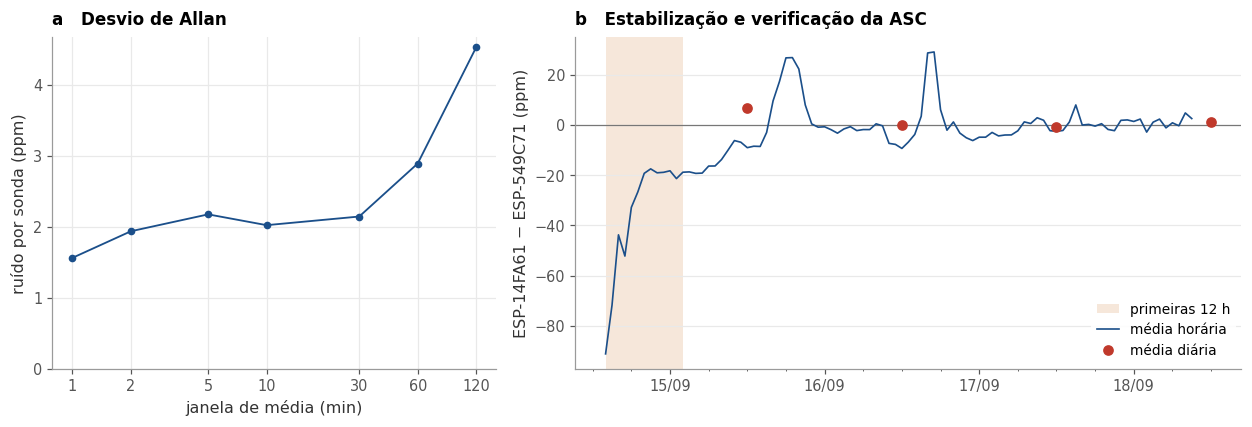

In [14]:
a_dem, b_dem = deming(val.co2_ppm_549C71, val.co2_ppm_14FA61)
print(f'Deming (λ = 1, erro nas duas sondas): 14FA61 = {a_dem:+.2f} + {b_dem:.4f} × 549C71')

d_ab = (par.co2_ppm_B - par.co2_ppm_A).asfreq('1min')                     # 14FA61 − 549C71, grade regular
ALLAN = allan(d_ab.loc[INICIO_ESTAVEL:], [1, 2, 5, 10, 30, 60, 120])
print('Desvio de Allan (ruído por sonda = desvio da diferença / √2): ' +
      ' | '.join(f'{m_} min: {v/np.sqrt(2):.2f} ppm' for m_, v in ALLAN.items()))
h = d_ab.resample('1h').mean().dropna(); dia_dif = d_ab.loc[INICIO_ESTAVEL:].resample('D').mean()
print(f'Diferença média nas primeiras 12 h: {h.iloc[:12].mean():+.1f} ppm | depois: {h.iloc[12:].mean():+.1f} ppm')
print('Média diária da diferença: ' + ', '.join(f'{t:%d/%m} {v:+.1f} ppm' for t, v in dia_dif.items()))
print('Mínimos diários (549C71 / 14FA61, ppm): ' + '; '.join(f'{t:%d/%m} {g_.co2_ppm_A.min():.0f} / {g_.co2_ppm_B.min():.0f}'
                                                           for t, g_ in par.groupby(par.index.date)))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4), gridspec_kw={'width_ratios': [1, 1.5]})
ax[0].plot(list(ALLAN), [v/np.sqrt(2) for v in ALLAN.values()], 'o-', color=COR['A'])
ax[0].set_xscale('log'); ax[0].set_xticks(list(ALLAN), [str(m_) for m_ in ALLAN]); ax[0].minorticks_off()
ax[0].set(xlabel='janela de média (min)', ylabel='ruído por sonda (ppm)', ylim=(0, None)); ax[0].grid(True, axis='both')
virgula(ax[0], 'y'); painel(ax[0], 'a', 'Desvio de Allan')
ax[1].axvspan(h.index[0], h.index[0] + pd.Timedelta(hours=12), color='#F6E7DA', lw=0, label='primeiras 12 h')
ax[1].axhline(0, color='#777777', lw=0.8)
ax[1].plot(h.index, h.values, color=COR['A'], lw=1.1, label='média horária')
ax[1].plot(dia_dif.index + pd.Timedelta(hours=12), dia_dif.values, 'o', color=COR['reg'], ms=6, label='média diária')
ax[1].set_ylabel(f'{MINHAS[1]} − {MINHAS[0]} (ppm)'); eixo_datas(ax[1]); ax[1].legend(loc='lower right')
painel(ax[1], 'b', 'Estabilização e verificação da ASC')
plt.tight_layout(); plt.show()

---
## Parte 3 — Dica do final da aula: balanço de massa, $C_0$ = atmosfera, $Q_{10}$ / Arrhenius

| Câmara | Equação do quadro |
|---|---|
| Estática ideal | $\dfrac{dC}{dt} = \text{Resp} - \text{Fotossíntese}$ |
| Com troca de ar | $V\dfrac{dC}{dt} = Q\,C_0 - Q\,C(t) \pm \text{Reações}$, com $C_0$ = **atmosfera** |
| Temperatura | Respiração → $T$: $Q_{10}$ / Arrhenius |

Como a câmara não está vedada, ela é tratada pela segunda equação, com $Q$ = vazamento pela borda do pote. Em forma molar, com $\tau = V/Q$:

$$n_{ar}\frac{dC}{dt} = \frac{n_{ar}}{\tau}(C_0 - C) + S, \qquad S = R_{eco} - \text{PB}$$

In [15]:
rs5 = lambda b_: df[df.board_id == b_][['co2_ppm', 'temperature_c']].resample('5min').mean()
Dm = pd.DataFrame({'C_a': rs5(MINHAS[0]).co2_ppm, 'C_b': rs5(MINHAS[1]).co2_ppm,
                   'T': (rs5(MINHAS[0]).temperature_c + rs5(MINHAS[1]).temperature_c)/2})
Dm['C'] = (Dm.C_a + Dm.C_b)/2
Dm['C_ext'] = pd.concat([rs5(x_).co2_ppm for x_ in FLUXO], axis=1).mean(axis=1)
Dm['elev'] = elevacao_solar(Dm.index); Dm['valido'] = True
for t0, t1, _ in EXCLUIR: Dm.loc[t0:t1, 'valido'] = False
noite_m = Dm.valido & (Dm.elev < -6)          # sem luz: PB = 0
dia_m = Dm.valido & (Dm.elev > 5)
suav = lambda s_: s_.where(Dm.valido).rolling('30min', center=True, min_periods=5).mean()
Dm['Cs'] = suav(Dm.C)
Dm['dCdt'] = np.gradient(Dm.Cs.values, (Dm.index - Dm.index[0]).total_seconds()/3600)     # ppm/h
Dm['n'] = P_ATM*V_AR/(R_GAS*(Dm['T'] + 273.15))                                          # mol de ar
print(f'{len(Dm)} médias de 5 min | {noite_m.sum()} noturnas válidas | {dia_m.sum()} diurnas válidas')

1102 médias de 5 min | 359 noturnas válidas | 197 diurnas válidas


### 3.1 Câmara estática ideal: à noite, $dC/dt$ deveria ser a respiração

In [16]:
linhas = []
for lab, (t0, t1) in NOITES.items():
    s_ = Dm.loc[t0:t1][noite_m.loc[t0:t1]]
    th = np.asarray((s_.index - s_.index[0]).total_seconds()/3600)
    inc = np.polyfit(th, s_.C.values, 1)[0]
    linhas.append({'noite': lab, 'dC/dt (ppm/h)': inc, "'respiração' (nmol/s)": s_.n.mean()*inc/3.6})
display(pd.DataFrame(linhas).set_index('noite').style.format('{:+.2f}'))
print('Respiração negativa ou nula: fisicamente impossível → a câmara não está vedada.')

,dC/dt (ppm/h),'respiração' (nmol/s)
noite,,
15–16/09,-6.11,-0.27
16–17/09,-5.35,-0.23
17–18/09,-0.45,-0.02


Respiração negativa ou nula: fisicamente impossível → a câmara não está vedada.


### 3.2 Equação com troca de ar, $C_0$ = atmosfera

À noite (PB = 0), a equação vira uma **regressão linear**: $\dfrac{dC}{dt} = \dfrac{1}{\tau}(C_0 - C) + \dfrac{R_{eco}}{n_{ar}}$. Os intervalos de confiança usam erros-padrão de Newey-West, porque as médias de 30 min consecutivas são autocorrelacionadas.

- **(a) atmosfera constante** — valor lido pelas próprias sondas quando expostas ao ar externo;
- **(b) atmosfera medida** — sondas das câmaras de fluxo, com o desvio δ entre sondas estimado nas aberturas.

,sondas do grupo (ppm),câmaras de fluxo (ppm)
abertura de 16/09,430.7,445.6
abertura de 17/09,407.4,433.2
1ª noite (câmara em equilíbrio),414.0,420.2


(a) C0 constante = 417.4 ppm   |   (b) C0(t) = câmaras de fluxo + δ, δ = -20.3 ppm


,τ (h),IC95% τ,R²,Q (L/h),R_eco (nmol/s),autocorr. resíduos
(a) constante,2.149963,1.21–9.55,0.339776,1.953522,1.623828,0.519498
(b) medida,1.382735,1.02–2.14,0.580592,3.037458,2.843867,0.361052


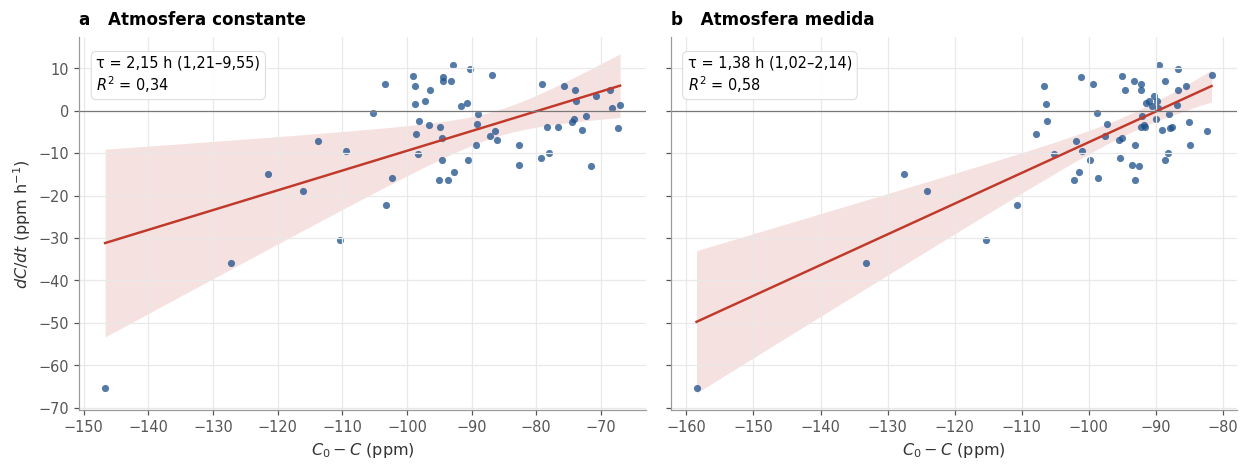

A atmosfera medida explica melhor a dinâmica noturna (maior R²) e é adotada daqui em diante.


In [17]:
C0_const = np.mean([Dm.C.loc[t0:t1].mean() for t0, t1 in AR_EXTERNO.values()])
DELTA = np.mean([(Dm.C - Dm.C_ext).loc[t0:t1].mean() for t0, t1 in list(AR_EXTERNO.values())[:2]])
display(pd.DataFrame({k_: {'sondas do grupo (ppm)': Dm.C.loc[t0:t1].mean(), 'câmaras de fluxo (ppm)': Dm.C_ext.loc[t0:t1].mean()}
                      for k_, (t0, t1) in AR_EXTERNO.items()}).T.style.format('{:.1f}'))
print(f'(a) C0 constante = {C0_const:.1f} ppm   |   (b) C0(t) = câmaras de fluxo + δ, δ = {DELTA:+.1f} ppm')

C0_opcoes = {'(a) constante': pd.Series(C0_const, index=Dm.index), '(b) medida': suav(Dm.C_ext) + DELTA}
REG = {}
for lab, C0s in C0_opcoes.items():
    N_ = Dm[noite_m].assign(C0=C0s[noite_m]).resample('30min').mean().dropna(subset=['dCdt', 'C0'])
    f_ = regressao(N_.C0 - N_.Cs, N_.dCdt)
    k_, r_ = f_.params[1], f_.params[0]; lo, hi = f_.conf_int()[1]
    REG[lab] = dict(k=k_, r=r_, R2=f_.rsquared, tau=1/k_, tau_lo=1/hi, tau_hi=1/lo, Q=V_AR*1e3*k_,
                    R=N_.n.mean()*r_/3.6, N=N_, fit=f_, aut=pd.Series(f_.resid).autocorr(1))
display(pd.DataFrame({k_: {'τ (h)': v['tau'], 'IC95% τ': f"{v['tau_lo']:.2f}–{v['tau_hi']:.2f}", 'R²': v['R2'],
                           'Q (L/h)': v['Q'], 'R_eco (nmol/s)': v['R'], 'autocorr. resíduos': v['aut']}
                      for k_, v in REG.items()}).T)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
for a_, (lab, v), letra in zip(ax, REG.items(), 'ab'):
    x_ = v['N'].C0 - v['N'].Cs; xl = np.linspace(x_.min(), x_.max(), 50)
    pred = v['fit'].get_prediction(sm.add_constant(xl)).summary_frame(alpha=0.05)
    a_.fill_between(xl, pred.mean_ci_lower, pred.mean_ci_upper, color=COR['reg'], alpha=0.15, lw=0)
    a_.plot(xl, pred['mean'], color=COR['reg'], lw=1.6)
    a_.scatter(x_, v['N'].dCdt, s=22, color=COR['A'], alpha=0.75, lw=0)
    a_.axhline(0, color='#777777', lw=0.8); a_.grid(True, axis='both')
    a_.set_xlabel('$C_0 - C$ (ppm)'); virgula(a_)
    caixa(a_, f"τ = {br(v['tau'])} h ({br(v['tau_lo'])}–{br(v['tau_hi'])})\n$R^2$ = {br(v['R2'])}")
    painel(a_, letra, f'Atmosfera {lab[4:]}')
ax[0].set_ylabel('$dC/dt$ (ppm h$^{-1}$)')
plt.tight_layout(); plt.show()
print('A atmosfera medida explica melhor a dinâmica noturna (maior R²) e é adotada daqui em diante.')

### 3.3 Constante de tempo pelos transientes (aberturas e picos de CO₂ na sala)

,τ (h),erro-padrão aprox. (h)
"17/09, após abertura",2.04,0.38
"16/09, após pico na sala",1.88,0.16
"15–16/09, relaxação noturna",1.04,0.05
ajuste conjunto das noites,1.10,—
regressão noturna (b),1.38,—


Adotado: τ = 1.5 h (faixa 1.1–2.1 h) → Q = V/τ = 2.8 L/h


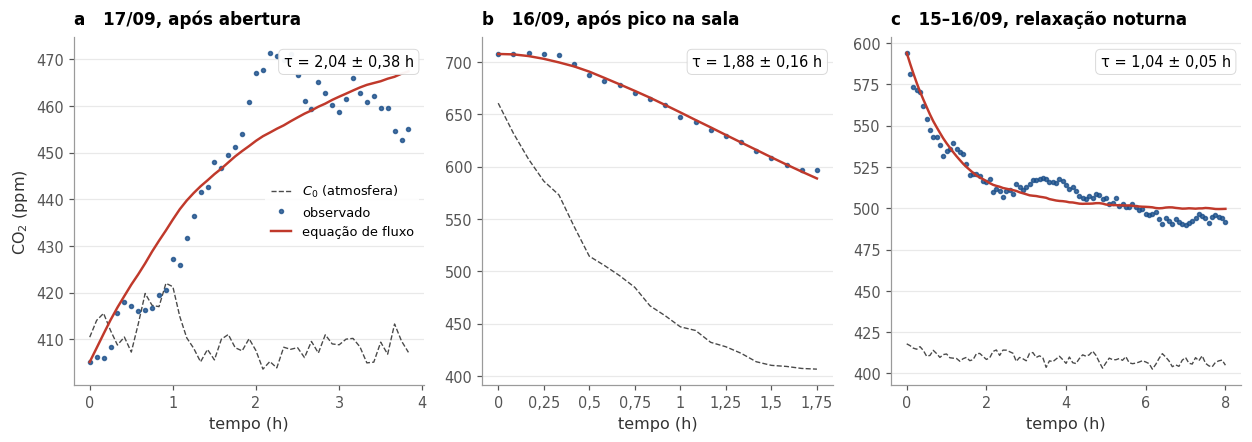

In [18]:
Dm['C0'] = Dm.C_ext + DELTA                                   # atmosfera medida (forçante)
EV = {}
for lab, (t0, t1) in EVENTOS.items():
    seg = Dm.loc[t0:t1]; p_, e_ = ajusta_transiente(seg); EV[lab] = (seg, p_, e_)
segs = [s_ for _, s_ in Dm[noite_m].groupby((noite_m != noite_m.shift()).cumsum()[noite_m]) if len(s_) >= 24]
obs_n = np.concatenate([s_.C.interpolate().values for s_ in segs])
fitN = least_squares(lambda p: np.concatenate([simula(s_, p[0], p[1]) for s_ in segs]) - obs_n,
                     x0=[1.5, 60], bounds=([0.1, 0], [20, 500]))
tab = pd.DataFrame({lab: {'τ (h)': p_[0], 'erro-padrão aprox. (h)': e_[0]} for lab, (_, p_, e_) in EV.items()}).T
tab.loc['ajuste conjunto das noites'] = [fitN.x[0], np.nan]
tab.loc['regressão noturna (b)'] = [REG['(b) medida']['tau'], np.nan]
display(tab.style.format('{:.2f}', na_rep='—'))
print(f'Adotado: τ = {TAU_H} h (faixa {TAU_FAIXA[0]}–{TAU_FAIXA[1]} h) → Q = V/τ = {V_AR*1e3/TAU_H:.1f} L/h')

def fig_tau(escala='notebook'):
    with plt.rc_context(estilo_params(escala)):
        w = 11.5 if escala == 'notebook' else 7.2
        fig, axs = plt.subplots(1, 3, figsize=(w, w*0.36))
        for a_, (lab, (seg, p_, e_)), letra in zip(axs, EV.items(), 'abc'):
            th = np.asarray((seg.index - seg.index[0]).total_seconds()/3600)
            a_.plot(th, seg.C0.values, color=COR['atm'], ls='--', lw=0.9, label='$C_0$ (atmosfera)')
            a_.plot(th, seg.C.values, 'o', ms=2.6, color=COR['A'], alpha=0.8, label='observado')
            a_.plot(th, simula(seg, p_[0], p_[1]), color=COR['reg'], lw=1.6, label='equação de fluxo')
            a_.set_xlabel('tempo (h)'); virgula(a_, 'x')
            painel(a_, letra, lab); caixa(a_, f'τ = {br(p_[0])} ± {br(e_[0])} h', x=0.97, ha='right')
        axs[0].set_ylabel('CO$_2$ (ppm)'); axs[0].legend(loc='center right', fontsize=mpl.rcParams['legend.fontsize'] - 0.5)
        plt.tight_layout()
    return fig
fig_tau(); plt.show()

### 3.4 Respiração noturna e troca líquida

$$S = n_{ar}\left[\frac{dC}{dt} + \frac{C - C_0}{\tau}\right] \qquad (\text{à noite}, \; S = R_{eco})$$

,R_eco (nmol/s)
noite 15–16/09,2.63
noite 16–17/09,2.54
noite 17–18/09,2.65
média das noites,2.60
"média, τ = 1.1 h",3.63
"média, τ = 2.1 h",1.80
"média, atmosfera constante (τ da regressão)",1.63


Respiração noturna: 2.60 nmol/s a 17.0 °C = 0.196 µmol m⁻² s⁻¹ por área de solo


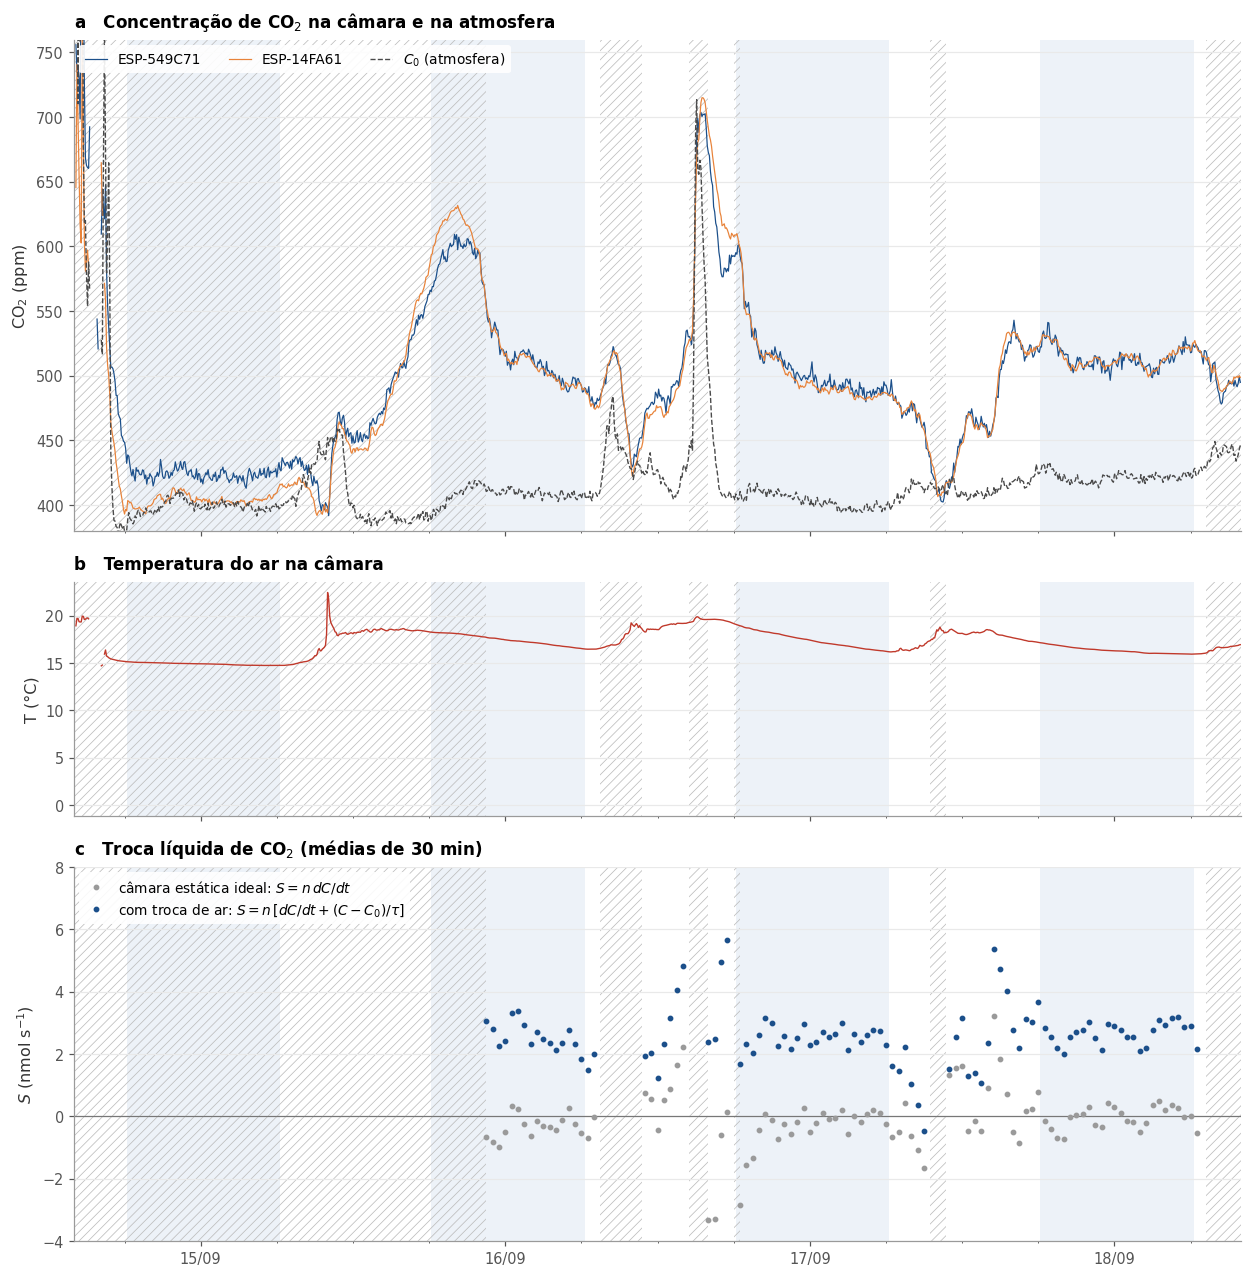

In [19]:
def balanco(tau=TAU_H, C0s=None):
    C0s = suav(Dm.C_ext) + DELTA if C0s is None else C0s
    return Dm.n*(Dm.dCdt + (Dm.Cs - C0s)/tau)/3600          # µmol/s
S = balanco(); Dm['S'] = S
SRn, Tn = S[noite_m].mean(), Dm['T'][noite_m].mean()
res = {f'noite {lab}': S.loc[t0:t1][noite_m.loc[t0:t1]].mean()*1e3 for lab, (t0, t1) in NOITES.items()}
res['média das noites'] = SRn*1e3
for tau in TAU_FAIXA: res[f'média, τ = {tau} h'] = balanco(tau)[noite_m].mean()*1e3
res['média, atmosfera constante (τ da regressão)'] = balanco(REG['(a) constante']['tau'], C0_opcoes['(a) constante'])[noite_m].mean()*1e3
display(pd.Series(res, name='R_eco (nmol/s)').to_frame().style.format('{:.2f}'))
print(f'Respiração noturna: {SRn*1e3:.2f} nmol/s a {Tn:.1f} °C = {SRn/A_SOLO:.3f} µmol m⁻² s⁻¹ por área de solo')

def fig_serie_balanco(escala='notebook'):
    with plt.rc_context(estilo_params(escala)):
        w = 11.5 if escala == 'notebook' else 7.2
        fig, ax = plt.subplots(3, 1, figsize=(w, w*1.02), sharex=True, gridspec_kw={'height_ratios': [2.1, 1, 1.6]})
        for a_ in ax: sombrear_noites(a_, Dm.index, Dm.elev); hachurar(a_, EXCLUIR)
        ax[0].plot(Dm.index, Dm.C_a, lw=0.8, color=COR['A'], label=MINHAS[0])
        ax[0].plot(Dm.index, Dm.C_b, lw=0.8, color=COR['B'], label=MINHAS[1])
        ax[0].plot(Dm.index, Dm.C_ext + DELTA, lw=0.9, color=COR['atm'], ls='--', label='$C_0$ (atmosfera)')
        ax[0].set_ylim(380, 760); ax[0].set_ylabel('CO$_2$ (ppm)'); ax[0].legend(loc='upper left', ncol=3)
        painel(ax[0], 'a', 'Concentração de CO$_2$ na câmara e na atmosfera')
        ax[1].plot(Dm.index, Dm['T'], lw=0.9, color=COR['reg']); ax[1].set_ylabel('T (°C)'); virgula(ax[1], 'y')
        painel(ax[1], 'b', 'Temperatura do ar na câmara')
        b30 = Dm[Dm.valido].resample('30min').mean(); ax[2].axhline(0, color='#777777', lw=0.8)
        ax[2].plot(b30.index, b30.n*b30.dCdt/3.6, 'o', ms=2.8, color='#9A9A9A', label=r'câmara estática ideal: $S = n\,dC/dt$')
        ax[2].plot(b30.index, b30.S*1e3, 'o', ms=2.8, color=COR['A'], label=r'com troca de ar: $S = n\,[dC/dt + (C - C_0)/\tau]$')
        ax[2].set_ylim(-4, 8); ax[2].set_ylabel('$S$ (nmol s$^{-1}$)'); ax[2].legend(loc='upper left')
        painel(ax[2], 'c', 'Troca líquida de CO$_2$ (médias de 30 min)')
        eixo_datas(ax[2]); ax[2].set_xlim(pd.Timestamp('2026-09-14 14:00'), pd.Timestamp('2026-09-18 10:00'))
        plt.tight_layout()
    return fig
fig_serie_balanco(); plt.show()

### 3.5 Respiração × temperatura: $Q_{10}$ e Arrhenius

**Definição** (Mundim et al., 2020, Eq. 1): $Q_{10} = \left(\dfrac{R_2}{R_1}\right)^{10/(T_2 - T_1)}$ — quanto a taxa se multiplica a cada 10 °C.

**Regressão** (várias temperaturas): $\ln R = a + bT \Rightarrow Q_{10} = e^{10b}$ &nbsp;·&nbsp; Arrhenius: $\ln R = a' - \dfrac{E_a}{R}\dfrac{1}{T_K}$ &nbsp;·&nbsp; verificação por ajuste não linear $R = R_{17}\,Q_{10}^{(T-17)/10}$.

In [20]:
def q10(Sser):
    bn = pd.DataFrame({'S': Sser[noite_m], 'T': Dm['T'][noite_m]}).resample('30min').mean().dropna()
    nneg = int((bn.S <= 0).sum()); bn = bn[bn.S > 0]
    f_ = regressao(bn['T'], np.log(bn.S*1e3)); lo, hi = f_.conf_int()[1]
    fa = regressao(1/(bn['T'] + 273.15), np.log(bn.S*1e3))
    p_, cv_ = curve_fit(lambda T, R17, q: R17*q**((T - 17)/10), bn['T'], bn.S*1e3, p0=[bn.S.mean()*1e3, 2])
    return bn, f_, dict(Q10=np.exp(10*f_.params[1]), lo=np.exp(10*lo), hi=np.exp(10*hi), R2=f_.rsquared,
                        Ea=-fa.params[1]*R_GAS/1e3, Q10_nl=p_[1], ep_nl=np.sqrt(cv_[1, 1]), descartados=nneg, n=len(bn))
Bn, lr, Q = q10(S)
_, _, Qc = q10(balanco(REG['(a) constante']['tau'], C0_opcoes['(a) constante']))
fitQ = least_squares(lambda p: np.concatenate([simula(s_, p[0], p[1], p[2]) for s_ in segs]) - obs_n,
                     x0=[1.5, 60, 2], bounds=([0.1, 0, 0.2], [20, 500, 10]))
display(pd.DataFrame({'atmosfera medida (adotada)': Q, 'atmosfera constante': Qc}).T.style.format(
    {'Q10': '{:.2f}', 'lo': '{:.2f}', 'hi': '{:.2f}', 'R2': '{:.2f}', 'Ea': '{:.0f}', 'Q10_nl': '{:.2f}', 'ep_nl': '{:.2f}',
     'descartados': '{:.0f}', 'n': '{:.0f}'}))
print(f'Ajuste direto do modelo às noites com Q10 livre: Q10 = {fitQ.x[2]:.2f}')
sens = [q10(balanco(t_, suav(Dm.C_ext) + d_))[2]['Q10'] for t_ in (1.1, 1.5, 2.1) for d_ in (-10, -20, -30)]
print(f'Sensibilidade (τ de 1,1 a 2,1 h; δ de −10 a −30 ppm): Q10 de {min(sens):.2f} a {max(sens):.2f}')
print(f"T noturna de {Bn['T'].min():.1f} a {Bn['T'].max():.1f} °C: com Q10 = 2 a respiração variaria "
      f"{100*(2**((Bn['T'].max() - Bn['T'].min())/10) - 1):.0f}%, da ordem da dispersão das estimativas "
      f"(CV = {100*Bn.S.std()/Bn.S.mean():.0f}%) → Q10 não identificável com estes dados.")

# Q10 pela definição, entre pares de noites (Mundim et al., 2020, Eq. 1)
NOITES_TAB = pd.DataFrame({lab: {'R (nmol/s)': S.loc[t0:t1][noite_m.loc[t0:t1]].mean()*1e3,
                                 'T (°C)': Dm['T'].loc[t0:t1][noite_m.loc[t0:t1]].mean()}
                           for lab, (t0, t1) in NOITES.items()}).T
PARES = []
for i in range(len(NOITES_TAB)):
    for j in range(i + 1, len(NOITES_TAB)):
        (R1, T1), (R2, T2) = NOITES_TAB.iloc[i], NOITES_TAB.iloc[j]
        PARES.append({'par de noites': f'{NOITES_TAB.index[i]} × {NOITES_TAB.index[j]}', 'ΔT (°C)': T2 - T1,
                      'R2/R1': R2/R1, 'Q10 = (R2/R1)^(10/ΔT)': (R2/R1)**(10/(T2 - T1))})
PARES = pd.DataFrame(PARES).set_index('par de noites')
print('\nQ10 pela definição, entre pares de noites:')
display(NOITES_TAB.style.format('{:.2f}')); display(PARES.style.format('{:.2f}'))
print(f'As noites diferem no máximo {br(PARES["ΔT (°C)"].abs().max(), 1)} °C. O expoente 10/ΔT amplifica os erros: com ΔT = 1 °C, '
      f'um erro de 5% na respiração vira um fator {br(1.05**10)} no Q10.')

,Q10,lo,hi,R2,Ea,Q10_nl,ep_nl,descartados,n
atmosfera medida (adotada),0.61,0.31,1.21,0.06,-34,0.65,0.16,0,61
atmosfera constante,0.04,0.00,0.82,0.25,-222,0.13,0.06,0,61


Ajuste direto do modelo às noites com Q10 livre: Q10 = 1.21
Sensibilidade (τ de 1,1 a 2,1 h; δ de −10 a −30 ppm): Q10 de 0.11 a 1.06
T noturna de 16.0 a 18.8 °C: com Q10 = 2 a respiração variaria 22%, da ordem da dispersão das estimativas (CV = 14%) → Q10 não identificável com estes dados.

Q10 pela definição, entre pares de noites:


,R (nmol/s),T (°C)
15–16/09,2.63,17.14
16–17/09,2.54,17.43
17–18/09,2.65,16.34


,ΔT (°C),R2/R1,Q10 = (R2/R1)^(10/ΔT)
par de noites,,,
15–16/09 × 16–17/09,0.29,0.97,0.32
15–16/09 × 17–18/09,-0.80,1.01,0.91
16–17/09 × 17–18/09,-1.09,1.04,0.69


As noites diferem no máximo 1,1 °C. O expoente 10/ΔT amplifica os erros: com ΔT = 1 °C, um erro de 5% na respiração vira um fator 1,63 no Q10.


### 3.6 Fotossíntese diurna: PB = $R(T) - S$, com $R(T) = \bar{R}\,Q_{10}^{(T - \bar{T})/10}$ ($Q_{10}$ = 2 adotado)

,valor
troca líquida diurna (nmol/s),2.50
fração positiva (%),88.32
respiração estimada (nmol/s),2.80
fotossíntese média (nmol/s),0.31
fotossíntese / respiração (%),10.95
fotossíntese 11–13 h (nmol/s),0.77
fotossíntese 14–17 h (nmol/s),-0.75
"faixa (τ 1,1–2,1 h; Q10 1–3), mín.",-0.03
"faixa, máx.",0.74


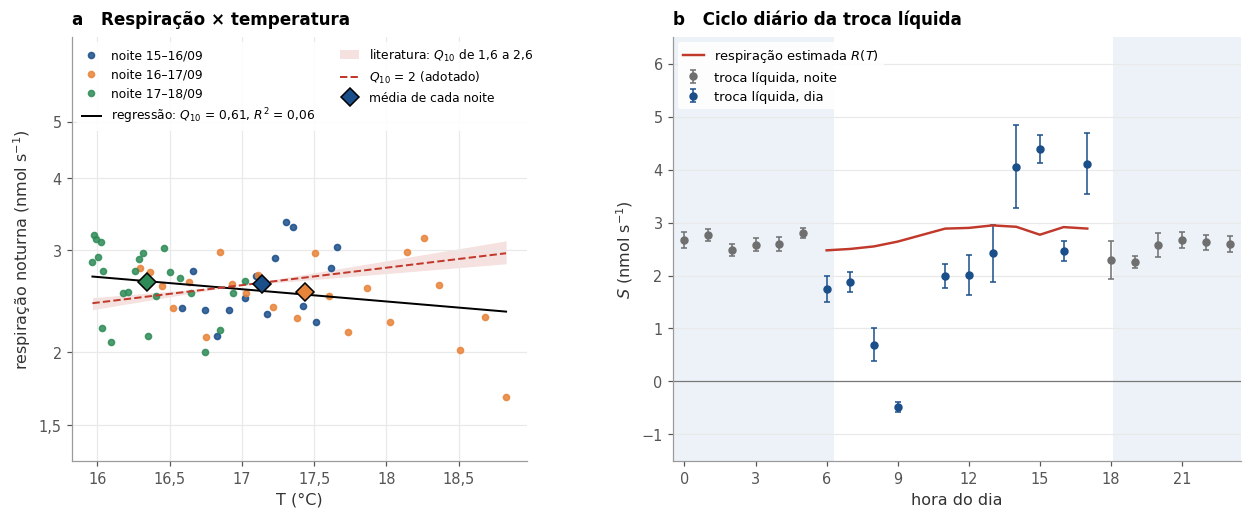

In [21]:
def diurno(Sser, q10_=Q10_ADOTADO):
    SR_ = Sser[noite_m].mean()*q10_**((Dm['T'][dia_m] - Dm['T'][noite_m].mean())/10)
    return pd.DataFrame({'S': Sser[dia_m], 'SR': SR_, 'PB': SR_ - Sser[dia_m], 'hora': Dm.index[dia_m].hour})
Bd = diurno(S)
faixa = [diurno(balanco(t_), q_).PB.mean()*1e3 for t_ in TAU_FAIXA for q_ in (1.0, 3.0)]
display(pd.Series({'troca líquida diurna (nmol/s)': Bd.S.mean()*1e3, 'fração positiva (%)': 100*(Bd.S > 0).mean(),
                   'respiração estimada (nmol/s)': Bd.SR.mean()*1e3, 'fotossíntese média (nmol/s)': Bd.PB.mean()*1e3,
                   'fotossíntese / respiração (%)': 100*Bd.PB.mean()/Bd.SR.mean(),
                   'fotossíntese 11–13 h (nmol/s)': Bd[Bd.hora.between(11, 13)].PB.mean()*1e3,
                   'fotossíntese 14–17 h (nmol/s)': Bd[Bd.hora.between(14, 17)].PB.mean()*1e3,
                   'faixa (τ 1,1–2,1 h; Q10 1–3), mín.': min(faixa), 'faixa, máx.': max(faixa)}).to_frame('valor').style.format('{:.2f}'))

def fig_q10(escala='notebook'):
    with plt.rc_context(estilo_params(escala)):
        w = 11.5 if escala == 'notebook' else 7.2
        fig, axs = plt.subplots(1, 2, figsize=(w, w*0.42), gridspec_kw={'width_ratios': [1, 1.25]})
        a_ = axs[0]
        for (lab, (t0, t1)), c_ in zip(NOITES.items(), [COR['A'], COR['B'], COR['M3']]):
            s_ = Bn.loc[t0:t1]; a_.plot(s_['T'], s_.S*1e3, 'o', ms=4, color=c_, alpha=0.85, label=f'noite {lab}')
        xx = np.linspace(Bn['T'].min(), Bn['T'].max(), 50)
        a_.plot(xx, np.exp(lr.params[0] + lr.params[1]*xx), color='black', lw=1.3,
                label=f"regressão: $Q_{{10}}$ = {br(Q['Q10'])}, $R^2$ = {br(Q['R2'])}")
        a_.fill_between(xx, SRn*1e3*Q10_LIT[0]**((xx - Tn)/10), SRn*1e3*Q10_LIT[1]**((xx - Tn)/10), color=COR['reg'],
                        alpha=0.15, lw=0, label=f'literatura: $Q_{{10}}$ de {br(Q10_LIT[0], 1)} a {br(Q10_LIT[1], 1)}')
        a_.plot(xx, SRn*1e3*2**((xx - Tn)/10), color=COR['reg'], ls='--', lw=1.3, label='$Q_{10}$ = 2 (adotado)')
        for k_, ((lab, _), c_) in enumerate(zip(NOITES.items(), [COR['A'], COR['B'], COR['M3']])):
            a_.plot(NOITES_TAB.loc[lab, 'T (°C)'], NOITES_TAB.loc[lab, 'R (nmol/s)'], 'D', ms=8, color=c_, mec='black', mew=1,
                    zorder=6, label='média de cada noite' if k_ == 0 else None)
        a_.set_yscale('log'); a_.set_ylim(1.3, 7); a_.set_yticks([1.5, 2, 3, 4, 5], ['1,5', '2', '3', '4', '5']); a_.minorticks_off()
        a_.set(xlabel='T (°C)', ylabel='respiração noturna (nmol s$^{-1}$)'); virgula(a_, 'x'); a_.grid(True, axis='both')
        a_.legend(loc='upper left', ncol=2, fontsize=mpl.rcParams['legend.fontsize'] - 1); painel(a_, 'a', 'Respiração × temperatura')
        a_ = axs[1]; se = lambda v: v.std()/np.sqrt(len(v))
        pf = Bd.groupby('hora').agg(S=('S', 'mean'), se=('S', se), SR=('SR', 'mean'), n=('S', 'size')); pf = pf[pf.n >= 6]
        pnx = pd.DataFrame({'S': S[noite_m], 'hora': Dm.index[noite_m].hour})
        pn = pnx.groupby('hora').agg(S=('S', 'mean'), se=('S', se), n=('S', 'size')); pn = pn[pn.n >= 6]
        a_.axvspan(-0.5, 6.3, color=COR['noite'], lw=0, zorder=0); a_.axvspan(18.1, 23.5, color=COR['noite'], lw=0, zorder=0)
        a_.axhline(0, color='#777777', lw=0.8)
        a_.errorbar(pn.index, pn.S*1e3, yerr=2*pn.se*1e3, fmt='o', ms=4.5, color='#6F6F6F', capsize=2, lw=1, label='troca líquida, noite')
        a_.errorbar(pf.index, pf.S*1e3, yerr=2*pf.se*1e3, fmt='o', ms=4.5, color=COR['A'], capsize=2, lw=1, label='troca líquida, dia')
        a_.plot(pf.index, pf.SR*1e3, '-', color=COR['reg'], lw=1.6, label='respiração estimada $R(T)$')
        a_.set(xlim=(-0.5, 23.5), ylim=(-1.5, 6.5), xticks=range(0, 24, 3), xlabel='hora do dia', ylabel='$S$ (nmol s$^{-1}$)')
        virgula(a_, 'y'); a_.legend(loc='upper left', fontsize=mpl.rcParams['legend.fontsize'] - 0.5)
        painel(a_, 'b', 'Ciclo diário da troca líquida')
        plt.tight_layout()
    return fig
fig_q10(); plt.show()

### 3.7 Efeito da correção das sondas (Parte 2) sobre a respiração e o $Q_{10}$

In [22]:
def com_correcao(Cx):
    dl = np.mean([(Cx - Dm.C_ext).loc[t0:t1].mean() for t0, t1 in list(AR_EXTERNO.values())[:2]])
    Csx = Cx.where(Dm.valido).rolling('30min', center=True, min_periods=5).mean()
    dCx = np.gradient(Csx.values, (Dm.index - Dm.index[0]).total_seconds()/3600)
    Sx = Dm.n*(dCx + (Csx - (suav(Dm.C_ext) + dl))/TAU_H)/3600
    bn = pd.DataFrame({'S': Sx[noite_m], 'T': Dm['T'][noite_m]}).resample('30min').mean().dropna(); bn = bn[bn.S > 0]
    return {'δ (ppm)': dl, 'R_eco (nmol/s)': Sx[noite_m].mean()*1e3, 'Q10': np.exp(10*stats.linregress(bn['T'], np.log(bn.S)).slope)}
display(pd.DataFrame({'média das sondas, sem correção (adotado)': com_correcao((Dm.C_a + Dm.C_b)/2),
                      'corrigida — janela, sem intercepto': com_correcao((a1*Dm.C_a + Dm.C_b)/2),
                      'corrigida — janela, com intercepto': com_correcao((b0 + b1*Dm.C_a + Dm.C_b)/2),
                      'corrigida — período estável, com intercepto': com_correcao((c0_est + c1_est*Dm.C_a + Dm.C_b)/2),
                      'somente ESP-549C71': com_correcao(Dm.C_a), 'somente ESP-14FA61': com_correcao(Dm.C_b)}).T.style.format('{:.2f}'))

,δ (ppm),R_eco (nmol/s),Q10
"média das sondas, sem correção (adotado)",-20.34,2.60,0.61
"corrigida — janela, sem intercepto",-52.94,2.42,0.63
"corrigida — janela, com intercepto",-24.24,2.22,0.66
"corrigida — período estável, com intercepto",-24.56,2.73,0.60
somente ESP-549C71,-19.28,2.60,0.72
somente ESP-14FA61,-21.40,2.61,0.51


### 3.8 Avaliação dos modelos nas noites

M0 exige respiração de -0.35 nmol/s (negativa) para se ajustar às noites


,r,DP normalizado,RMSE (ppm)
M0 — estática ideal,0.22,2.26,36.99
"M1 — troca de ar, R constante",0.94,1.04,5.95
"M2 — troca de ar, R(T) com Q10 = 2",0.89,1.10,7.95
"M3 — troca de ar, ajuste direto",0.94,0.96,5.31


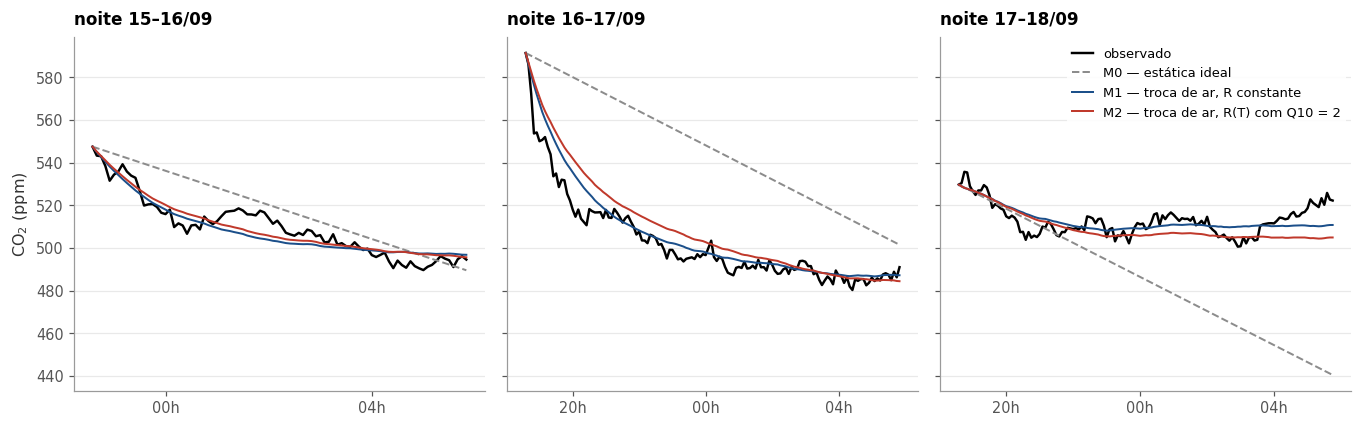

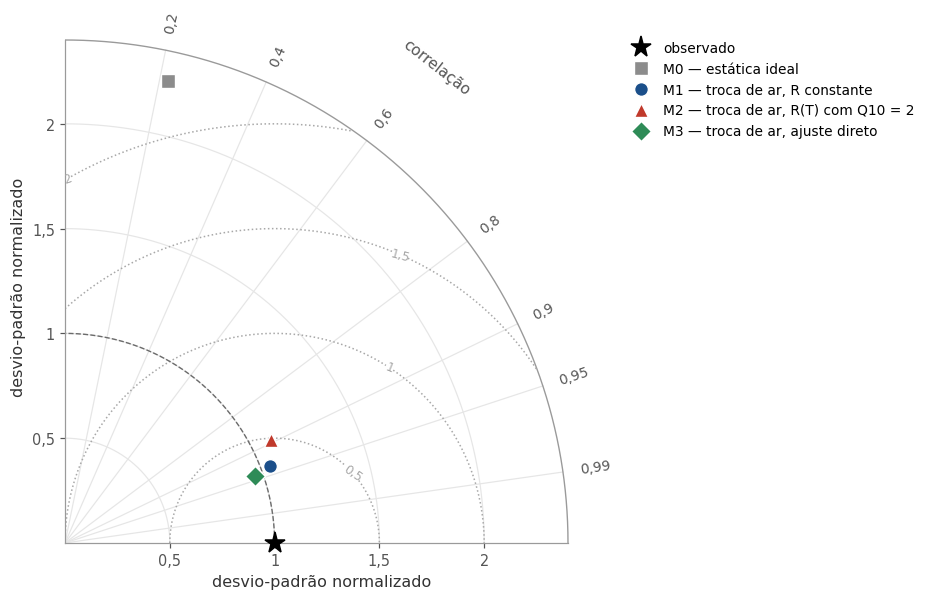

In [23]:
nbar = Dm.n[noite_m].mean(); r_med = SRn*1e3/nbar*3.6
fit0 = least_squares(lambda p: np.concatenate([simula(s_, 1, p[0], sem_vaz=True) for s_ in segs]) - obs_n, x0=[0])
MODELOS = {'M0 — estática ideal': dict(f=lambda s_: simula(s_, 1, fit0.x[0], sem_vaz=True), cor=COR['M0'], m='s'),
           'M1 — troca de ar, R constante': dict(f=lambda s_: simula(s_, TAU_H, r_med), cor=COR['M1'], m='o'),
           'M2 — troca de ar, R(T) com Q10 = 2': dict(f=lambda s_: simula(s_, TAU_H, r_med, 2.0), cor=COR['M2'], m='^'),
           'M3 — troca de ar, ajuste direto': dict(f=lambda s_: simula(s_, fitN.x[0], fitN.x[1]), cor=COR['M3'], m='D')}
for v in MODELOS.values(): v['sim'] = np.concatenate([v['f'](s_) for s_ in segs])
AVM = pd.DataFrame({k_: {'r': np.corrcoef(obs_n, v['sim'])[0, 1], 'DP normalizado': v['sim'].std()/obs_n.std(),
                         'RMSE (ppm)': np.sqrt(np.mean((v['sim'] - obs_n)**2))} for k_, v in MODELOS.items()}).T
print(f'M0 exige respiração de {nbar*fit0.x[0]/3.6:.2f} nmol/s (negativa) para se ajustar às noites')
display(AVM.style.format('{:.2f}'))

fig, axs = plt.subplots(1, len(segs), figsize=(12.5, 4), sharey=True)
for a_, s_, lab in zip(axs, segs, NOITES):
    a_.plot(s_.index, s_.C, color='black', lw=1.6, label='observado')
    for k_, v in MODELOS.items():
        if k_.startswith('M3'): continue
        a_.plot(s_.index, v['f'](s_), color=v['cor'], lw=1.3, ls='--' if k_.startswith('M0') else '-', label=k_)
    a_.xaxis.set_major_locator(mdates.HourLocator(byhour=[20, 0, 4])); a_.xaxis.set_major_formatter(mdates.DateFormatter('%Hh'))
    painel(a_, '', f'noite {lab}')
axs[0].set_ylabel('CO$_2$ (ppm)'); axs[-1].legend(loc='upper right', fontsize=8.5)
plt.tight_layout(); plt.show()

def fig_taylor_modelos(escala='notebook'):
    with plt.rc_context(estilo_params(escala)):
        w = 9 if escala == 'notebook' else 6.2
        fig, ax = plt.subplots(figsize=(w, w*0.62))
        taylor(ax, 1.0, [dict(rotulo=k_, dp=AVM.loc[k_, 'DP normalizado'], r=AVM.loc[k_, 'r'], cor=v['cor'], marcador=v['m'])
                         for k_, v in MODELOS.items()], unidade=None, rmax=2.4, rticks=[0.5, 1, 1.5, 2],
               niveis=[0.5, 1, 1.5, 2], rotulo_ref='observado')
        ax.legend(loc='upper left', bbox_to_anchor=(1.08, 1))
        plt.tight_layout()
    return fig
fig_taylor_modelos(); plt.show()

### 3.9 Comparação com a literatura

- **Machado et al. (2005)** mediram, em câmara foliar com controle de luz e temperatura, a respiração no escuro de citros (após 20 min de escuro) e o ponto de compensação luminoso das folhas. Os valores são por **área de folha**; os deste experimento, por **área do vaso** e incluindo o substrato — a comparação é de ordem de grandeza.
- **Mundim et al. (2020)** mostram que o $Q_{10}$ não é constante: para respiração foliar (dados de Heskel et al., 2016), a razão entre taxas separadas por 10 °C fica entre 1,6 e 2,6 na faixa de 15 a 40 °C, maior nas temperaturas baixas.

In [24]:
# (1) respiração: citros convertidos para a temperatura noturna da câmara
conv = [r_*Q10_ADOTADO**((Tn - T_CITROS)/10) for r_ in R_CITROS]
print(f'Citros, respiração no escuro: {br(R_CITROS[0])}–{br(R_CITROS[1])} µmol m⁻² s⁻¹ de folha a {T_CITROS:.0f} °C '
      f'→ {br(conv[0])}–{br(conv[1])} a {br(Tn, 1)} °C (Q10 = {br(Q10_ADOTADO, 0)})')
print(f'Fitônia + substrato: {br(SRn/A_SOLO)} µmol m⁻² s⁻¹ por área do vaso '
      f'(= {100*SRn/A_SOLO/np.mean(conv):.0f}% do valor dos citros, mesmo incluindo o substrato)')
print(f'Ponto de compensação luminoso de folhas de citros: {br(PC_CITROS[0], 1)}–{br(PC_CITROS[1], 1)} µmol m⁻² s⁻¹ de PAR; '
      'no conjunto planta + substrato, a respiração do substrato eleva esse limiar.')

# (2) Q10 da literatura: quanto a respiração deveria variar na faixa de temperatura das noites
dT = Bn['T'].max() - Bn['T'].min()
print(f'\nFaixa de T noturna: {br(dT, 1)} °C → variação esperada da respiração com Q10 de {br(Q10_LIT[0], 1)} a {br(Q10_LIT[1], 1)}: '
      f'{100*(Q10_LIT[0]**(dT/10) - 1):.0f}% a {100*(Q10_LIT[1]**(dT/10) - 1):.0f}% — mesma ordem da dispersão das estimativas '
      f'(CV = {100*Bn.S.std()/Bn.S.mean():.0f}%).')

# (3) sensibilidade da fotossíntese ao Q10 adotado
SENS_Q10 = pd.DataFrame({f'Q10 = {q_:g}': {'respiração diurna R(T) (nmol/s)': diurno(S, q_).SR.mean()*1e3,
                                            'fotossíntese média (nmol/s)': diurno(S, q_).PB.mean()*1e3}
                         for q_ in (1.0, Q10_LIT[0], 2.0, 2.5, Q10_LIT[1], 3.0)}).T
display(SENS_Q10.style.format('{:.2f}'))
print(f"Trocar Q10 = 2 por 2,5 muda a fotossíntese em {num(1e3*(diurno(S, 2.5).PB.mean() - diurno(S, 2.0).PB.mean()), 2, True)} nmol/s.")

Citros, respiração no escuro: 1,12–1,17 µmol m⁻² s⁻¹ de folha a 28 °C → 0,52–0,54 a 17,0 °C (Q10 = 2)
Fitônia + substrato: 0,20 µmol m⁻² s⁻¹ por área do vaso (= 37% do valor dos citros, mesmo incluindo o substrato)
Ponto de compensação luminoso de folhas de citros: 12,0–17,5 µmol m⁻² s⁻¹ de PAR; no conjunto planta + substrato, a respiração do substrato eleva esse limiar.

Faixa de T noturna: 2,9 °C → variação esperada da respiração com Q10 de 1,6 a 2,6: 14% a 31% — mesma ordem da dispersão das estimativas (CV = 14%).


,respiração diurna R(T) (nmol/s),fotossíntese média (nmol/s)
Q10 = 1,2.60,0.11
Q10 = 1.6,2.74,0.24
Q10 = 2,2.80,0.31
Q10 = 2.5,2.87,0.38
Q10 = 2.6,2.88,0.39
Q10 = 3,2.93,0.44


Trocar Q10 = 2 por 2,5 muda a fotossíntese em +0,07 nmol/s.


---
## Parte 4 — Figuras do relatório e resumo

As figuras são salvas em PDF na sessão (painel de arquivos, à esquerda); coloque-as na pasta `figuras/` do LaTeX.

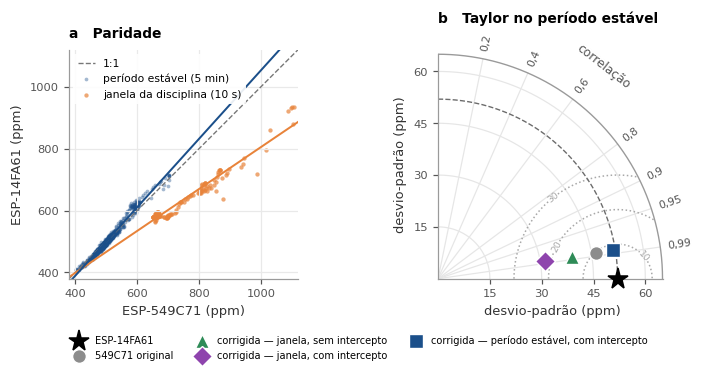

salva: fig_regressao_sondas.pdf


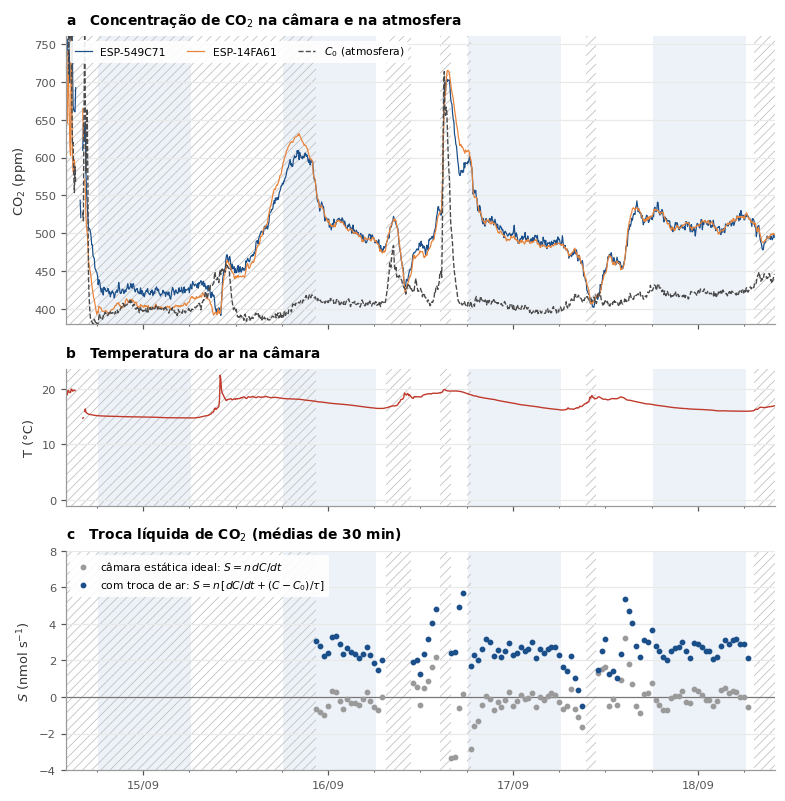

salva: fig_balanco_serie.pdf


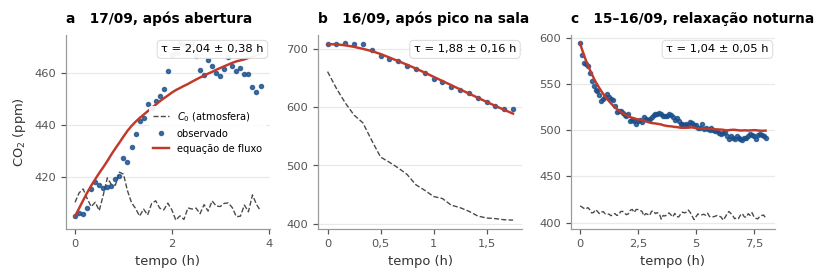

salva: fig_tau.pdf


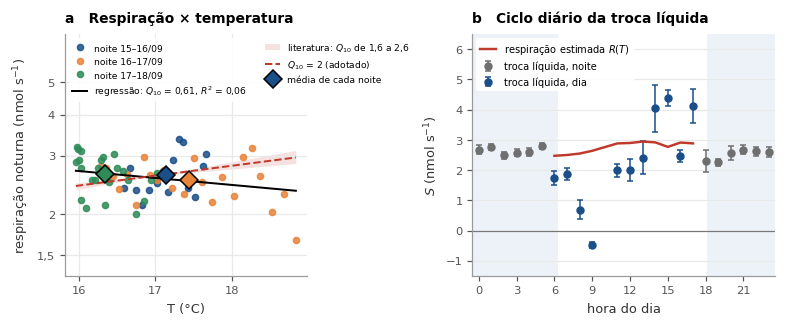

salva: fig_q10_diario.pdf


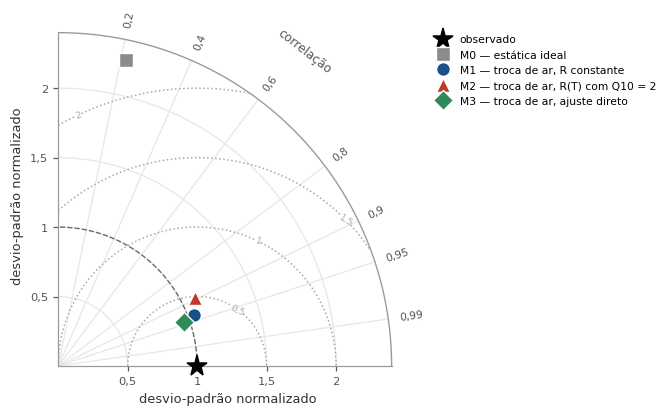

salva: fig_taylor.pdf


In [25]:
def fig_regressao(escala='relatorio'):
    with plt.rc_context(estilo_params(escala)):
        w = 11.5 if escala == 'notebook' else 7.2
        fig, ax = plt.subplots(1, 2, figsize=(w, w*0.47), gridspec_kw={'width_ratios': [1, 1.15]})
        v5 = val.resample('5min').mean().dropna()
        lim = np.array([380, 1120])
        ax[0].plot(lim, lim, color='#777777', ls='--', lw=0.9, label='1:1')
        ax[0].scatter(v5.co2_ppm_549C71, v5.co2_ppm_14FA61, s=6, color=COR['A'], alpha=0.4, lw=0, label='período estável (5 min)')
        ax[0].scatter(data.co2_ppm_549C71, data.co2_ppm_14FA61, s=8, color=COR['B'], alpha=0.7, lw=0, label='janela da disciplina (10 s)')
        ax[0].plot(lim, b0 + b1*lim, color=COR['B'], lw=1.3); ax[0].plot(lim, c0_est + c1_est*lim, color=COR['A'], lw=1.3)
        ax[0].set(xlim=lim, ylim=lim, xlabel=f'{MINHAS[0]} (ppm)', ylabel=f'{MINHAS[1]} (ppm)'); ax[0].set_aspect('equal')
        ax[0].grid(True, axis='both'); ax[0].legend(loc='upper left'); painel(ax[0], 'a', 'Paridade')
        taylor(ax[1], sd_ref_est, [dict(rotulo=k_, dp=v['desvio-padrão'], r=v['correlação'], cor=c_, marcador=m_)
                                   for (k_, v), c_, m_ in zip(met_estavel.iterrows(), cores_val, 'o^Ds')],
               rotulo_ref=f'{MINHAS[1]}', niveis=[10, 20, 30])
        h_, l_ = ax[1].get_legend_handles_labels()
        fig.legend(h_, l_, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.0), fontsize=mpl.rcParams['legend.fontsize'] - 0.5)
        painel(ax[1], 'b', 'Taylor no período estável', pad=18)
        plt.tight_layout(rect=[0, 0.1, 1, 1])
    return fig

FIGURAS = {'fig_regressao_sondas.pdf': fig_regressao, 'fig_balanco_serie.pdf': fig_serie_balanco, 'fig_tau.pdf': fig_tau,
           'fig_q10_diario.pdf': fig_q10, 'fig_taylor.pdf': fig_taylor_modelos}
for nome, funcao in FIGURAS.items():
    f_ = funcao('relatorio'); f_.savefig(nome); plt.show(); print('salva:', nome)

In [26]:
v_ = REG['(b) medida']
resumo = pd.DataFrame([
    ('Intercomparação', 'viés entre as sondas no período estável', f'{num(vies, 1, True)} ppm'),
    ('Intercomparação', 'RMSE da correção da janela (com intercepto) no período estável', f"{num(met_estavel.iloc[2]['RMSE'], 1)} ppm"),
    ('Atmosfera', 'C0 constante (lido pelas sondas do grupo no ar externo)', f'{num(C0_const, 0)} ppm'),
    ('Atmosfera', 'desvio δ entre sondas', f'{num(DELTA, 1, True)} ppm'),
    ('Vazamento', 'τ pela regressão noturna (atmosfera medida)', f"{num(v_['tau'], 2)} h (IC95% {num(v_['tau_lo'], 2)}–{num(v_['tau_hi'], 2)})"),
    ('Vazamento', 'τ adotado e vazão equivalente', f'{num(TAU_H, 1)} h → {num(V_AR*1e3/TAU_H, 1)} L/h'),
    ('Respiração', 'noturna, média (faixa por τ)', f"{num(SRn*1e3, 2)} nmol/s ({num(balanco(TAU_FAIXA[1])[noite_m].mean()*1e3, 1)}–{num(balanco(TAU_FAIXA[0])[noite_m].mean()*1e3, 1)})"),
    ('Respiração', 'por área de solo', f'{num(SRn/A_SOLO, 2)} µmol m⁻² s⁻¹'),
    ('Temperatura', 'Q10 pela regressão (IC95%)', f"{num(Q['Q10'], 2)} ({num(Q['lo'], 2)}–{num(Q['hi'], 2)}) → não identificável"),
    ('Temperatura', 'Q10 entre pares de noites (definição)', f"{num(PARES.iloc[:, -1].min(), 2)} a {num(PARES.iloc[:, -1].max(), 2)} (ΔT ≤ {num(PARES['ΔT (°C)'].abs().max(), 1)} °C)"),
    ('Temperatura', 'Q10 da literatura, respiração foliar (15–40 °C)', f'{num(Q10_LIT[0], 1)} a {num(Q10_LIT[1], 1)}'),
    ('Literatura', 'respiração de citros convertida para a T noturna', f'{num(conv[0], 2)}–{num(conv[1], 2)} µmol m⁻² s⁻¹ de folha'),
    ('Fotossíntese', 'média diurna (fração da respiração)', f'{num(Bd.PB.mean()*1e3, 2)} nmol/s ({num(100*Bd.PB.mean()/Bd.SR.mean(), 0)}%)'),
    ('Modelos', 'RMSE nas noites: M0 / M1', f"{num(AVM.iloc[0]['RMSE (ppm)'], 1)} / {num(AVM.iloc[1]['RMSE (ppm)'], 1)} ppm"),
], columns=['bloco', 'resultado', 'valor']).set_index(['bloco', 'resultado'])
display(resumo)

valor
bloco           resultado                                                                               
Intercomparação viés entre as sondas no período estável                                         +1,1 ppm
                RMSE da correção da janela (com intercepto) no ...                              43,6 ppm
Atmosfera       C0 constante (lido pelas sondas do grupo no ar ...                               417 ppm
                desvio δ entre sondas                                                          −20,3 ppm
Vazamento       τ pela regressão noturna (atmosfera medida)                     1,38 h (IC95% 1,02–2,14)
                τ adotado e vazão equivalente                                            1,5 h → 2,8 L/h
Respiração      noturna, média (faixa por τ)                                       2,60 nmol/s (1,8–3,6)
                por área de solo                                                       0,20 µmol m⁻² s⁻¹
Temperatura     Q10 pela regressão (IC95%)                          0,61 (0,31–1,21) → não identificável
                Q10 entre pares de noites (definição)                          0,32 a 0,91 (ΔT ≤ 1,1 °C)
                Q10 da literatura, respiração foliar (15–40 °C)                                1,6 a 2,6
Literatura      respiração de citros convertida para a T noturna         0,52–0,54 µmol m⁻² s⁻¹ de folha
Fotossíntese    média diurna (fração da respiração)                                    0,31 nmol/s (11%)
Modelos         RMSE nas noites: M0 / M1                                                  37,0 / 6,0 ppm

---
## Referências

- Atkin, O. K.; Tjoelker, M. G. (2003). Thermal acclimation and the dynamic response of plant respiration to temperature. *Trends in Plant Science*, 8(7), 343–351.
- Heskel, M. A. et al. (2016). Convergence in the temperature response of leaf respiration across biomes and plant functional types. *PNAS*, 113, 3832–3837.
- Lloyd, J.; Taylor, J. A. (1994). On the temperature dependence of soil respiration. *Functional Ecology*, 8(3), 315–323.
- Machado, E. C.; Schmidt, P. T.; Medina, C. L.; Ribeiro, R. V. (2005). Respostas da fotossíntese de três espécies de citros a fatores ambientais. *Pesquisa Agropecuária Brasileira*, 40(12), 1161–1170.
- Mundim, K. C.; Baraldi, S.; Machado, H. G.; Vieira, F. M. C. (2020). Temperature coefficient (Q10) and its applications in biological systems: beyond the Arrhenius theory. *Ecological Modelling*, 431, 109127.
- Reichstein, M. et al. (2005). On the separation of net ecosystem exchange into assimilation and ecosystem respiration. *Global Change Biology*, 11(9), 1424–1439.
- Taylor, K. E. (2001). Summarizing multiple aspects of model performance in a single diagram. *Journal of Geophysical Research*, 106(D7), 7183–7192.